# CSCI 3360 Project 

## Instructions

In [191]:
#!pip install matplotlib numpy pandas 
import numpy as np
import math
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns
# !pip install seaborn
# import statsmodels.api as sm

# run below code once to install ARIMA
# !pip install sktime
# from sktime.forecasting.arima import AutoARIMA
# from sktime.forecasting.model_selection import temporal_train_test_split
# from sktime.performance_metrics.forecasting import mean_absolute_error
# from sklearn.metrics import mean_squared_error

## Academic Honesty Statement

In [192]:
first_name_one = "Fidel"
last_name_one  = "Arroyo"
first_name_two = "Sanjana"
last_name_two= "Arun"


print("****************************************************************")
print("CSCI 3360 Project")
print(f"completed by {first_name_one} {last_name_one} and  {first_name_two} {last_name_two}")
print(f"""
We, GROUP 11: {first_name_one} {last_name_one} and {first_name_two} {last_name_two}, certify that the following code
represents our own work. We have neither received nor given 
inappropriate assistance. We have not consulted with another
individual, other than a member of the teaching staff, regarding
the specifics of our project. We recognize that any 
unauthorized assistance or plagiarism will be handled in 
accordance with the University of Georgia's Academic Honesty
Policy and the policies of this course.
""")
print("****************************************************************")

****************************************************************
CSCI 3360 Project
completed by Fidel Arroyo and  Sanjana Arun

We, GROUP 11: Fidel Arroyo and Sanjana Arun, certify that the following code
represents our own work. We have neither received nor given 
inappropriate assistance. We have not consulted with another
individual, other than a member of the teaching staff, regarding
the specifics of our project. We recognize that any 
unauthorized assistance or plagiarism will be handled in 
accordance with the University of Georgia's Academic Honesty
Policy and the policies of this course.

****************************************************************


## Loading 

We will first load the data and have the orginal pd as wage_data.

In [193]:
wage_data = pd.read_csv('./median_average_wages.csv')

In [194]:
print(f"Shape: {wage_data.shape}")
print(f"Rows: {wage_data.shape[0]}")
print(f"Columns: {wage_data.shape[1]}")

Shape: (50, 31)
Rows: 50
Columns: 31


In [195]:
group_dfs = []
group_train = []
group_test = []
year_df = wage_data["year"]
split = math.floor(year_df.shape[0] * 0.20)
year_test = year_df[:split]
year_train = year_df[split:]
print(f"Split year is {year_df[split]}, so we are testing for any year after {year_df[split]}")

correlation_storage = []
median_storage = []

Split year is 2012, so we are testing for any year after 2012


##  Exploratory Data Analysis

We will showcase our Exploratory Data analysis:  mean, minimum and maximum, and standard deviation for a training set (80%) split. We will also display the histograms for each categorical group.

In [196]:
i = 0;
for group in wage_data.columns:
    if (i > 0):
        temp_df = wage_data[group].dropna()
        test = temp_df[:split]
        train = temp_df[split:]
        trim = train.describe(include=np.number).loc[ ['mean', 'std', 'min', 'max', '50%'] ]
        print(f"Train {group}")
        print(trim)
        correlation = train.corr(year_train)
        print(f"Correlation between {group} and year: {correlation}")
        print()
        print()
        group_dfs.append(temp_df)
        group_train.append(train)
        group_test.append(test)
        correlation_storage.append([group, correlation])
        median_storage.append([group, train.median()])
    i+=1

Train median
mean    19.857750
std      0.875075
min     18.780000
max     21.450000
50%     19.385000
Name: median, dtype: float64
Correlation between median and year: 0.7829267929893973


Train average
mean    24.497000
std      1.880201
min     22.420000
max     27.900000
50%     23.700000
Name: average, dtype: float64
Correlation between average and year: 0.9258716327106336


Train men_median
mean    23.083250
std      0.797619
min     21.510000
max     24.270000
50%     23.260000
Name: men_median, dtype: float64
Correlation between men_median and year: -0.296969590750943


Train men_average
mean    27.880750
std      1.599648
min     26.200000
max     31.150000
50%     26.990000
Name: men_average, dtype: float64
Correlation between men_average and year: 0.8324766914479996


Train women_median
mean    17.00050
std      1.56914
min     14.88000
max     19.57000
50%     16.75000
Name: women_median, dtype: float64
Correlation between women_median and year: 0.9764693117738396


Train w

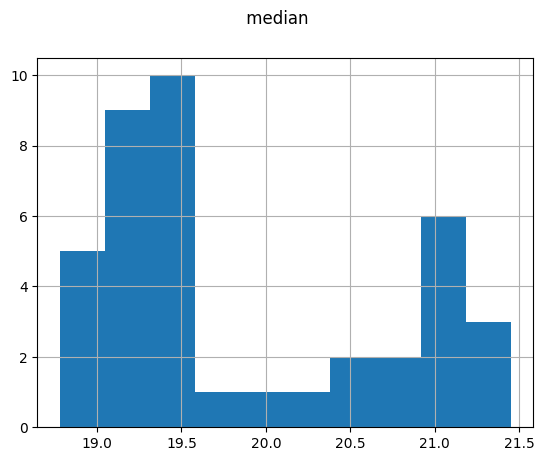

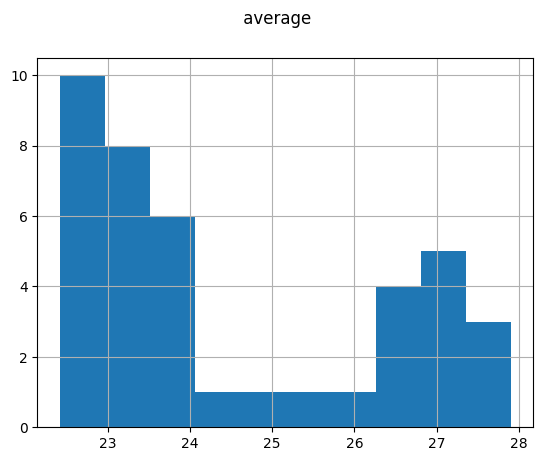

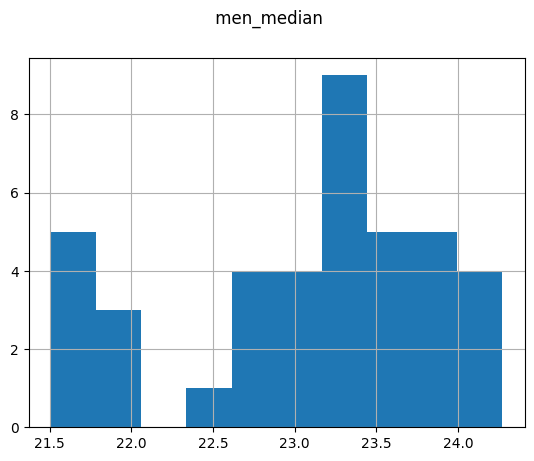

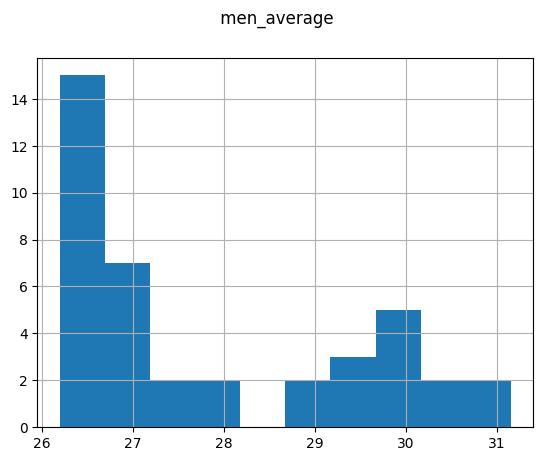

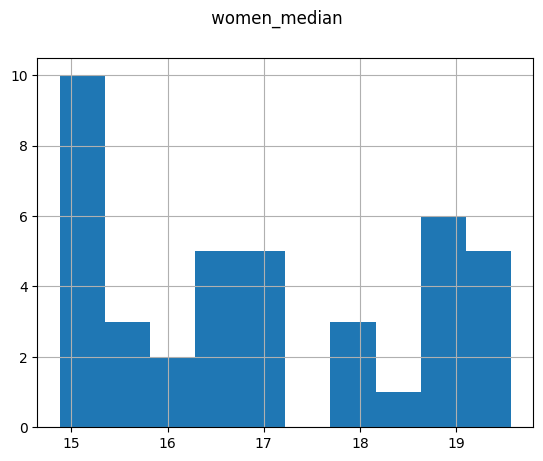

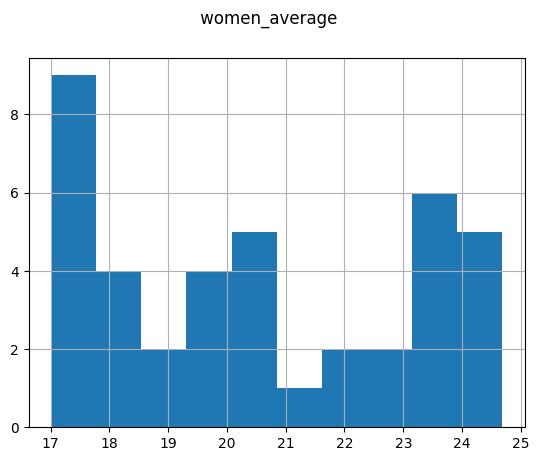

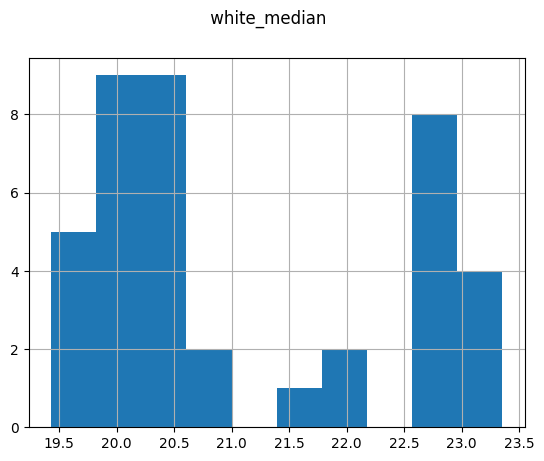

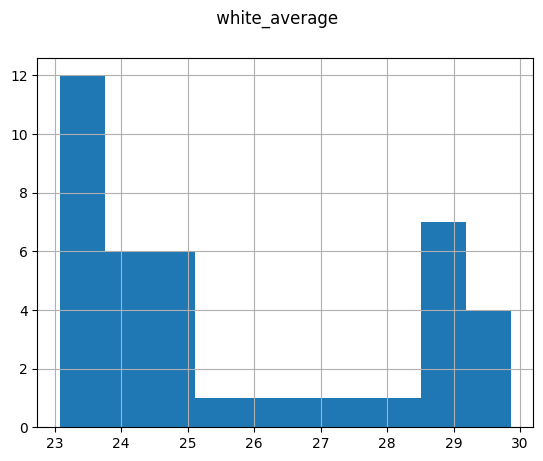

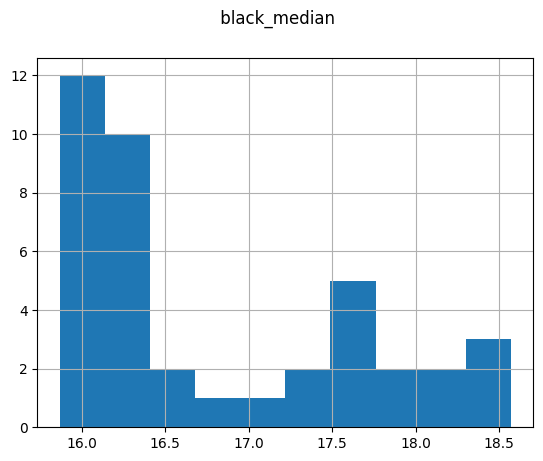

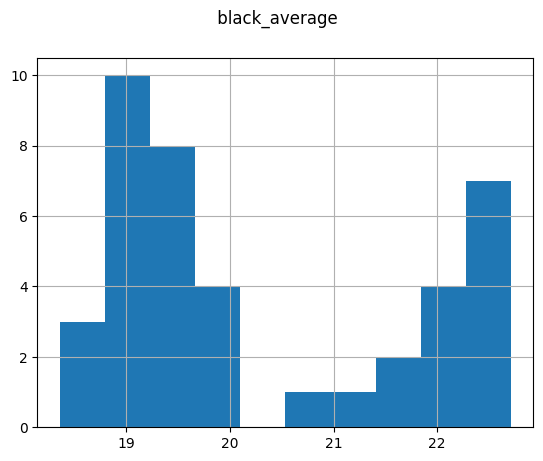

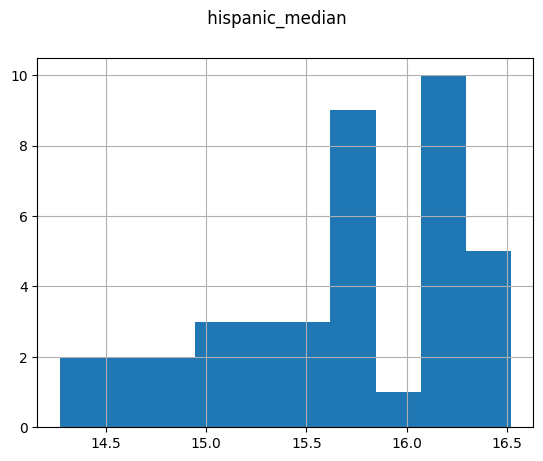

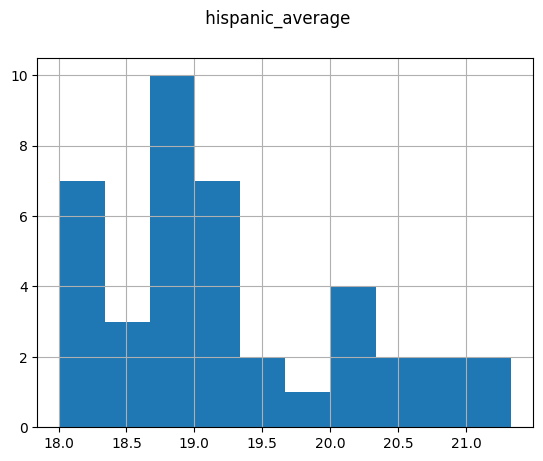

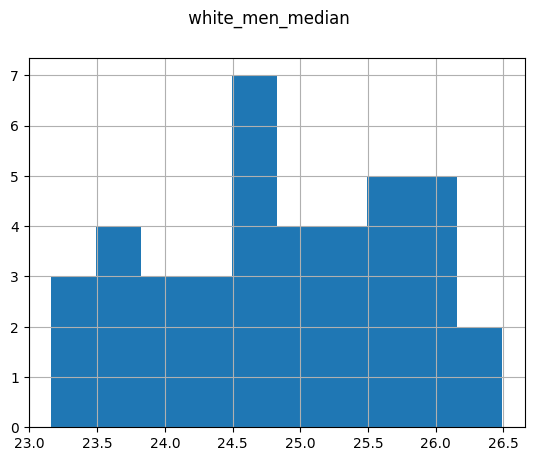

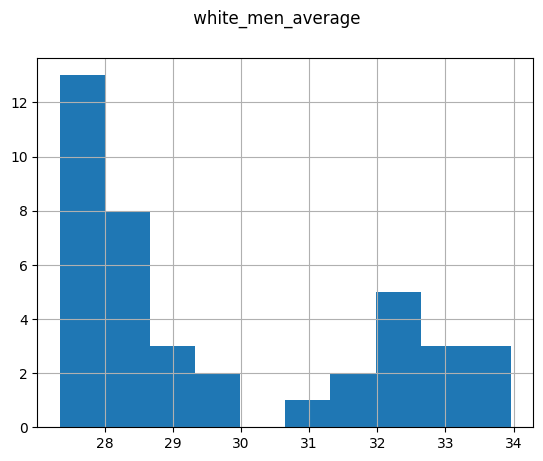

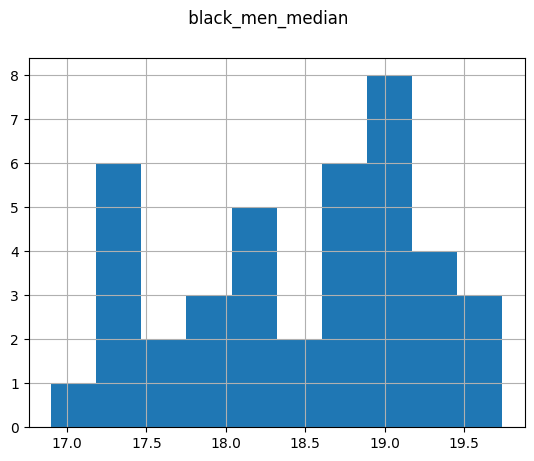

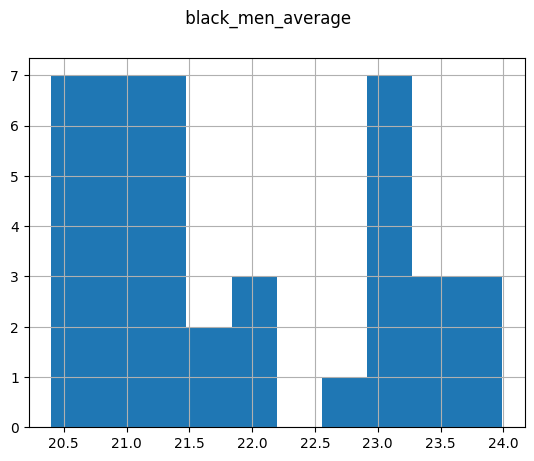

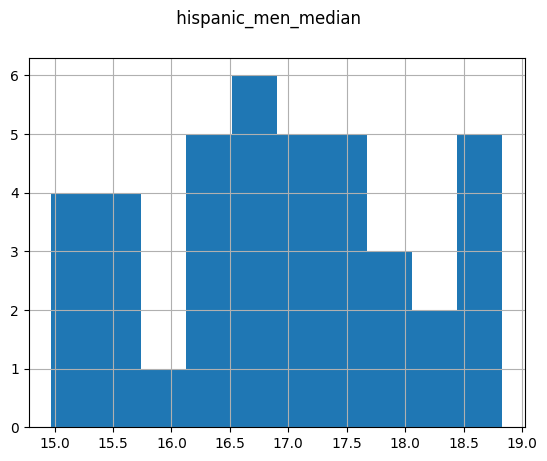

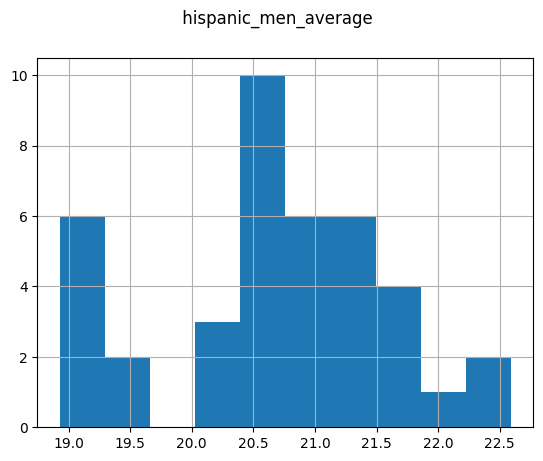

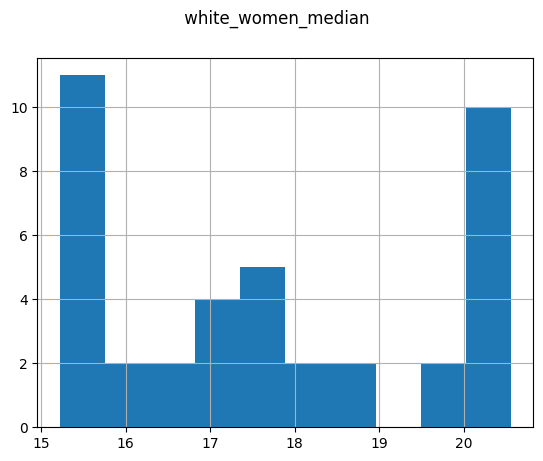

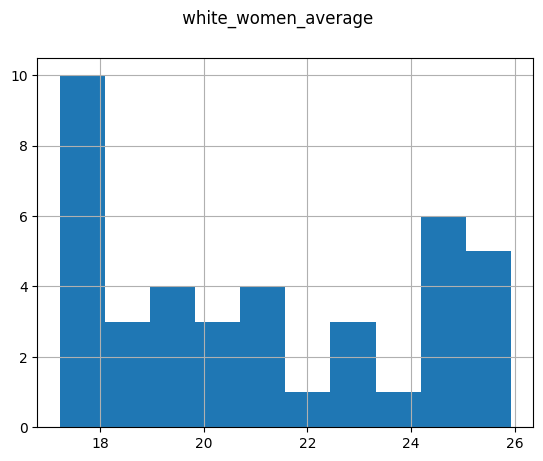

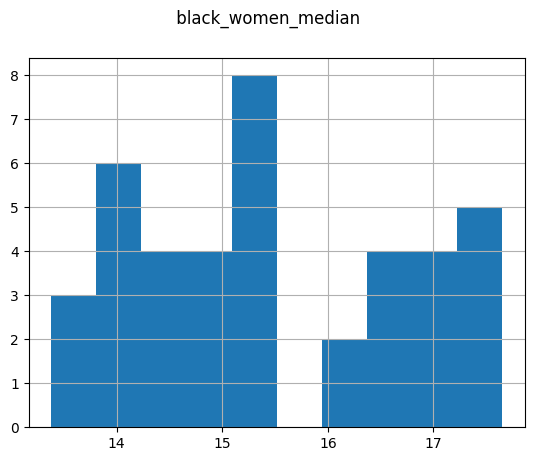

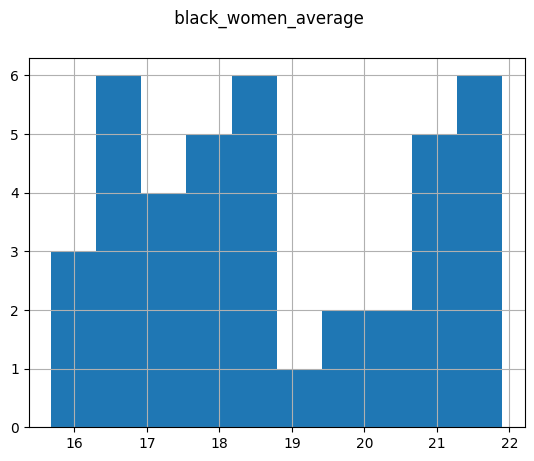

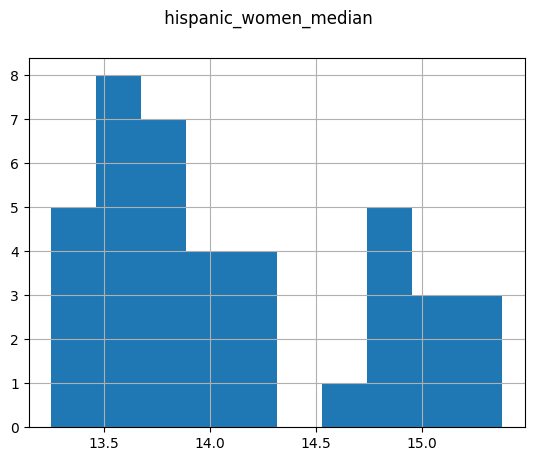

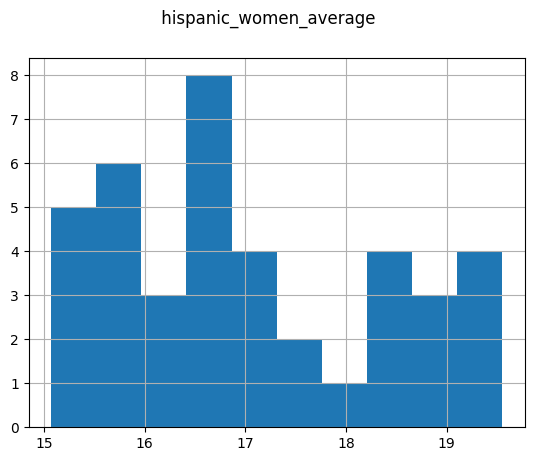

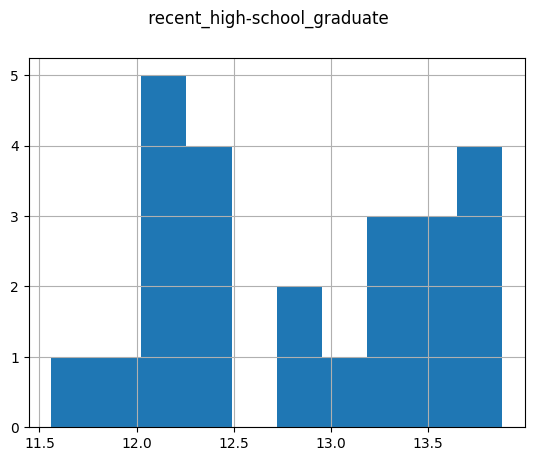

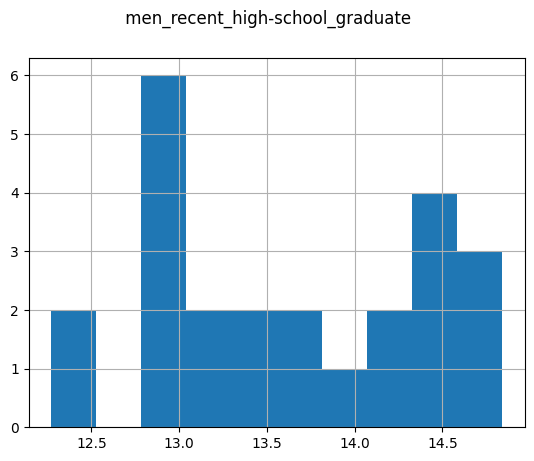

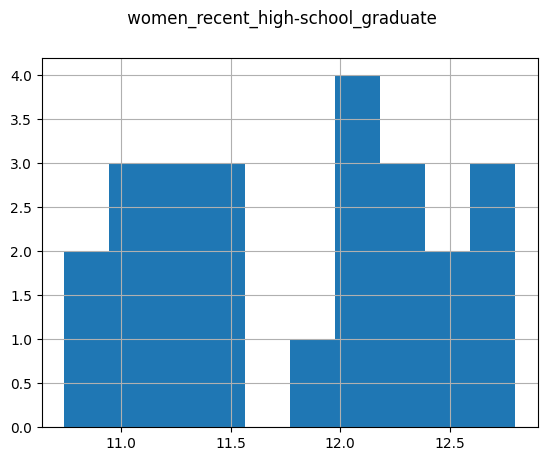

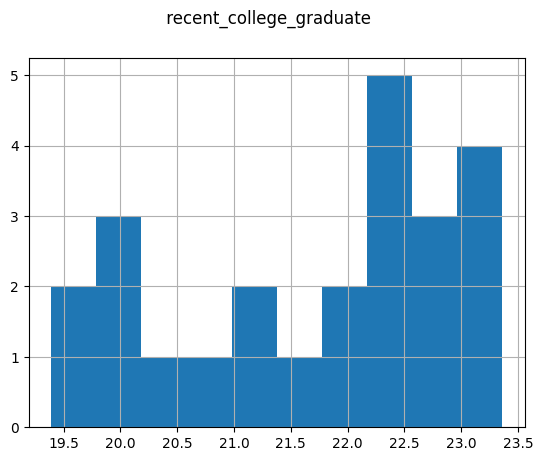

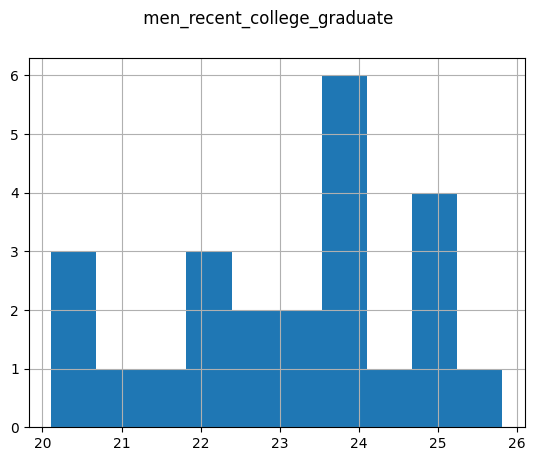

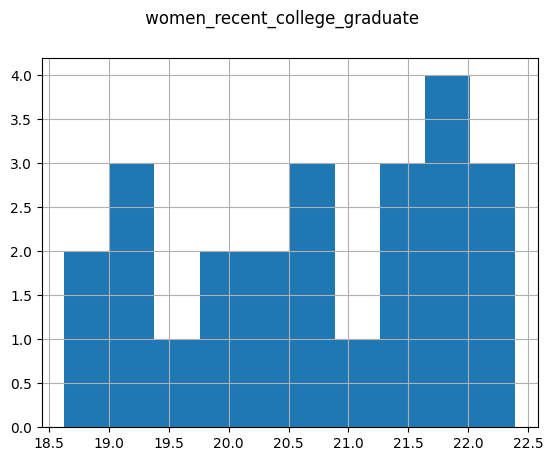

In [197]:
i = 1
cols = wage_data.columns[i:]
for  df in group_train:
    plt.figure()
    df.hist()
    plt.suptitle(f" {cols[i - 1]} ")
    i += 1
    plt.show()
    plt.close()

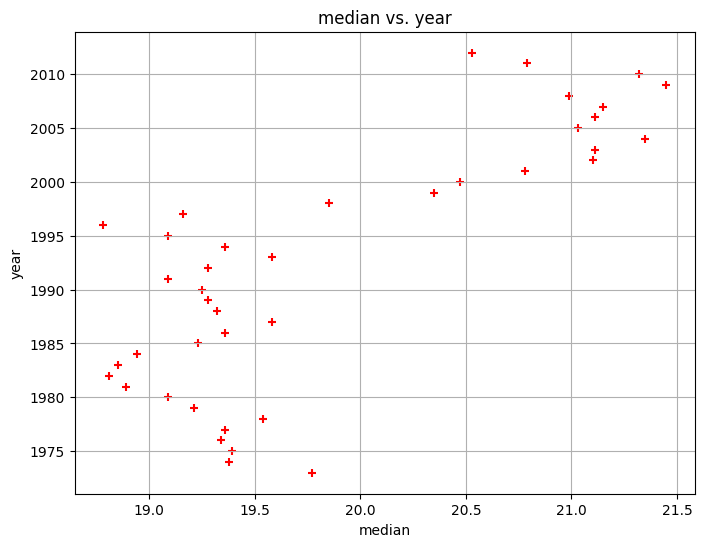

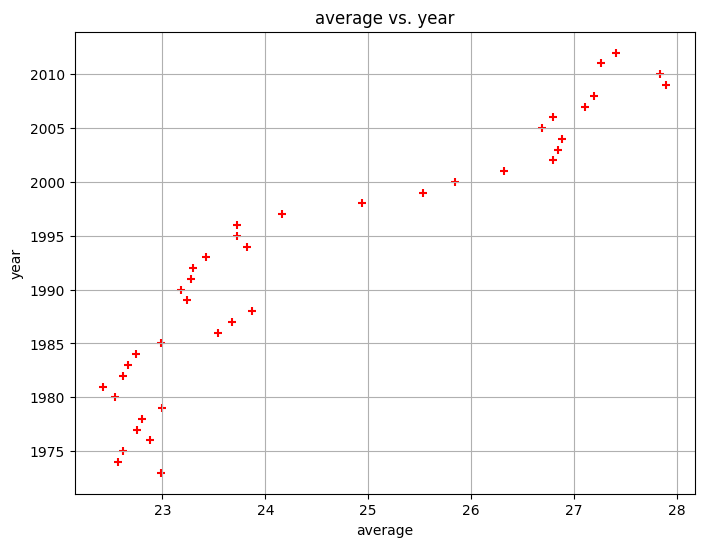

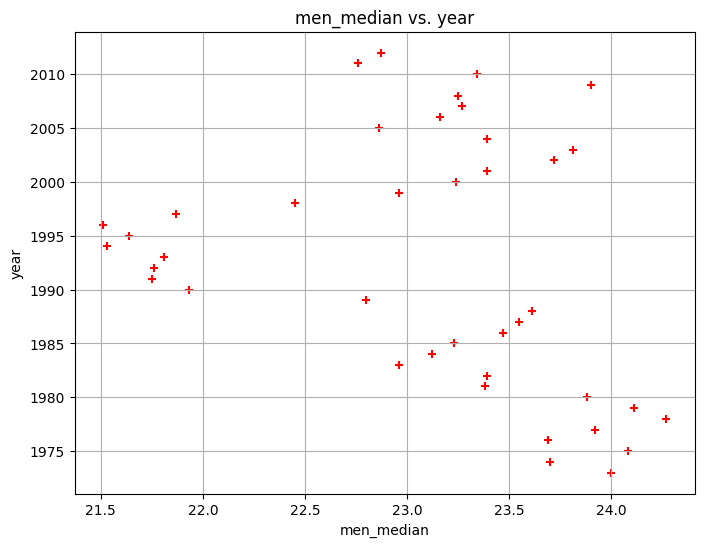

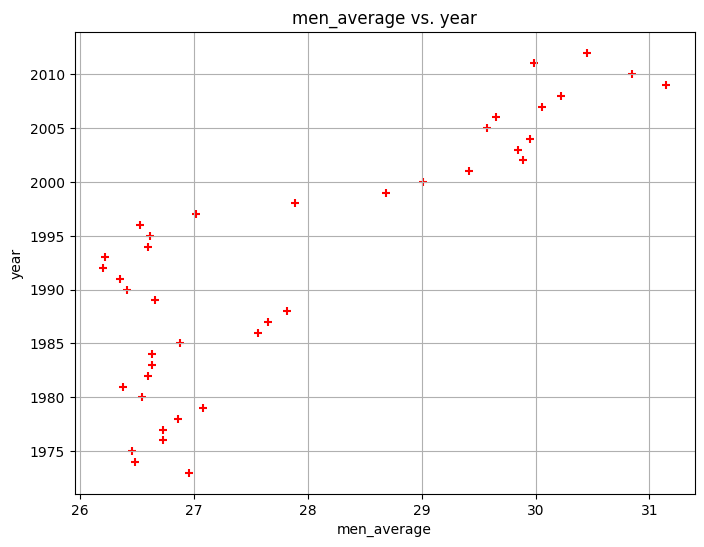

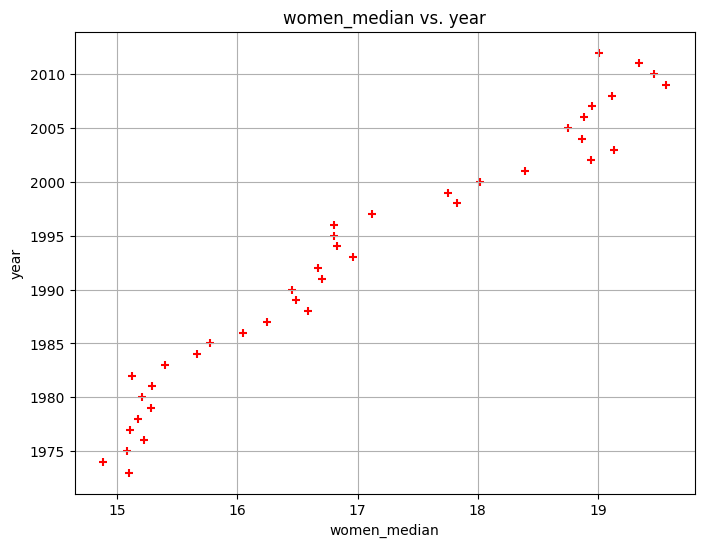

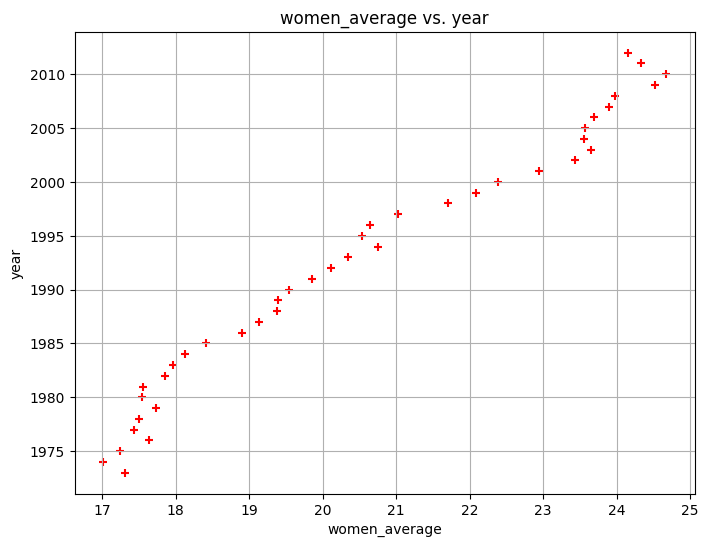

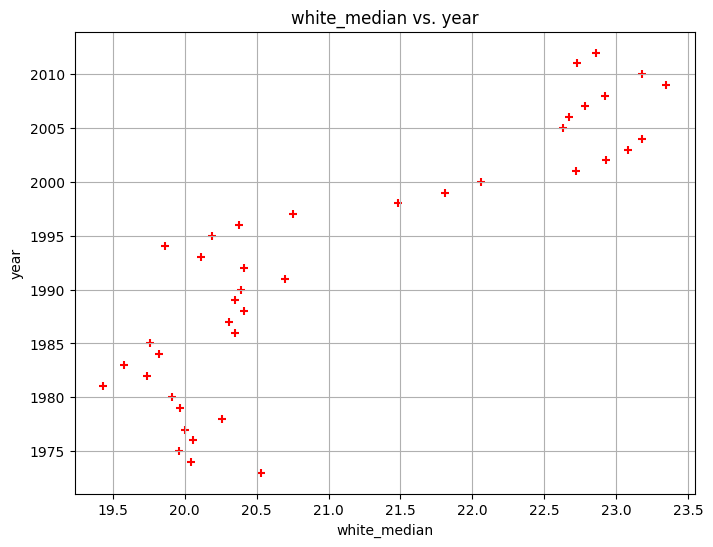

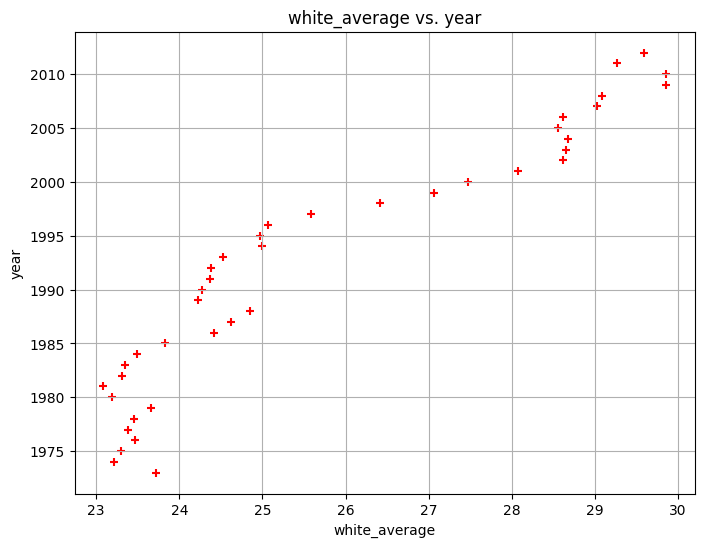

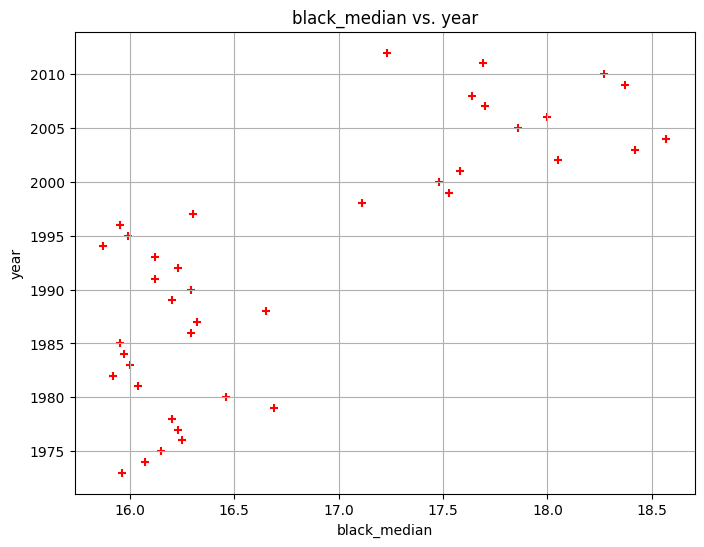

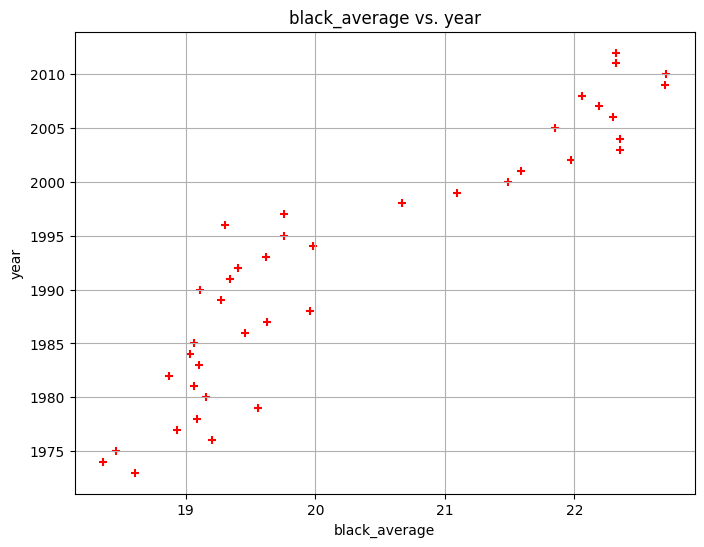

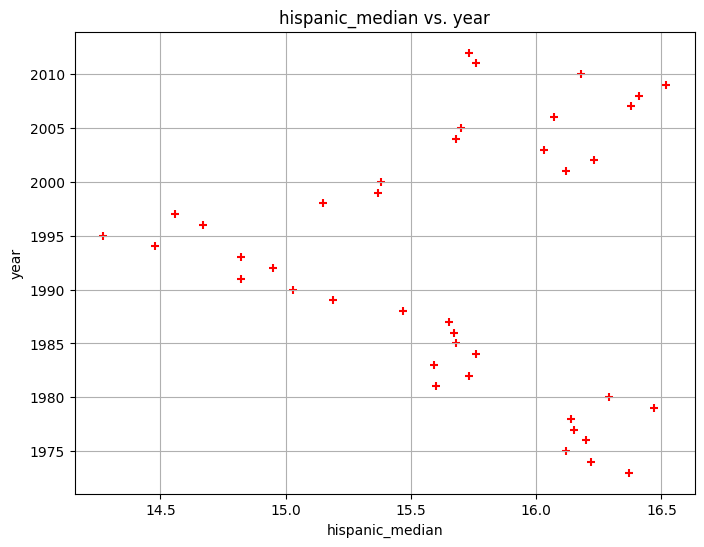

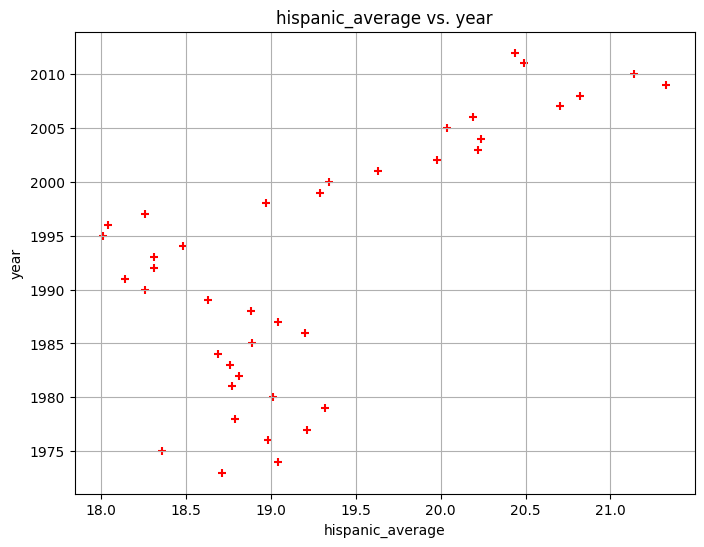

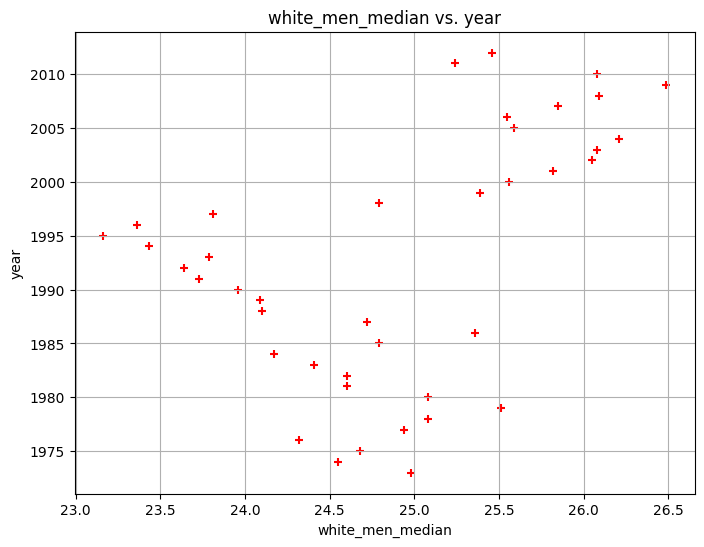

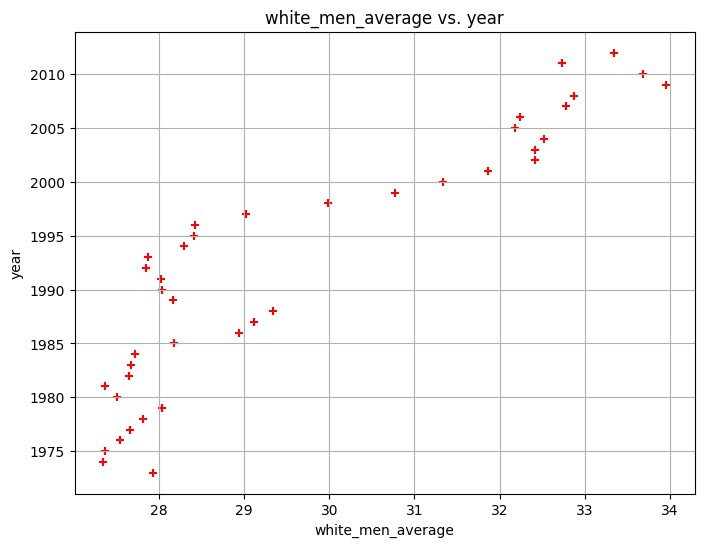

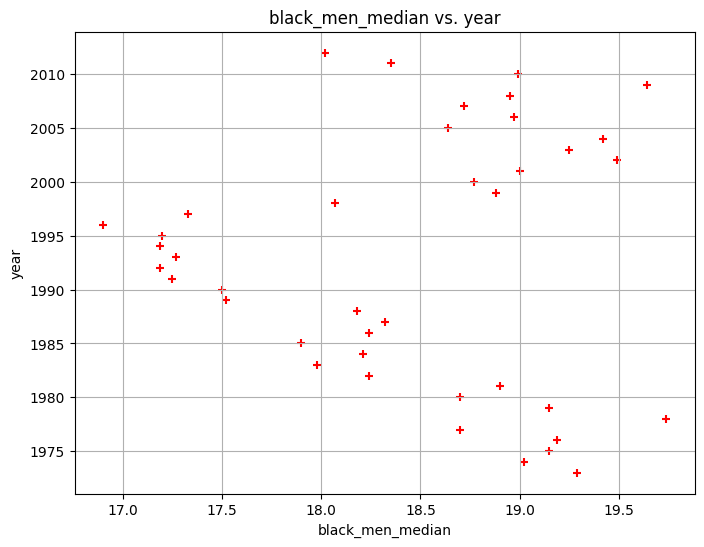

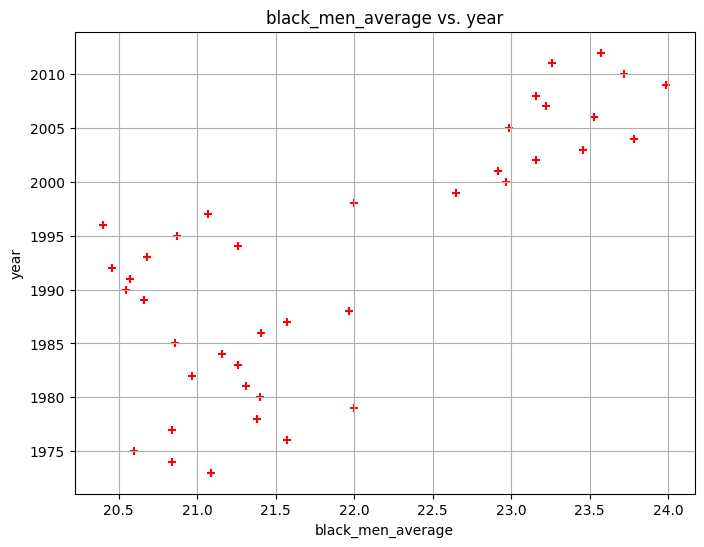

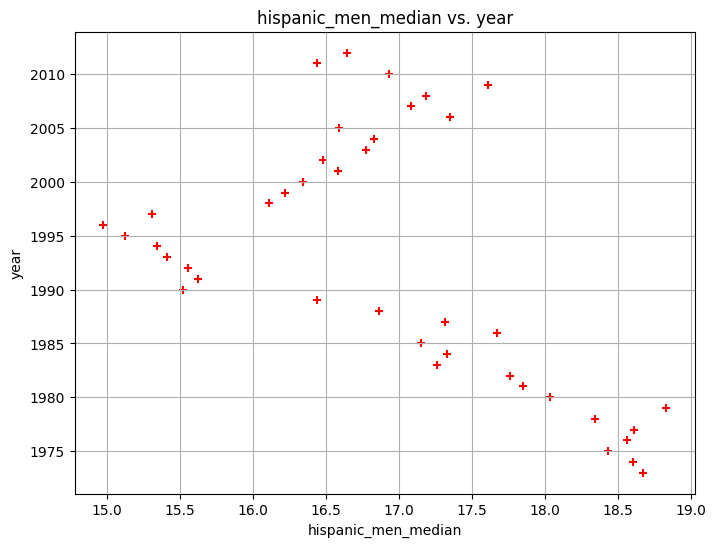

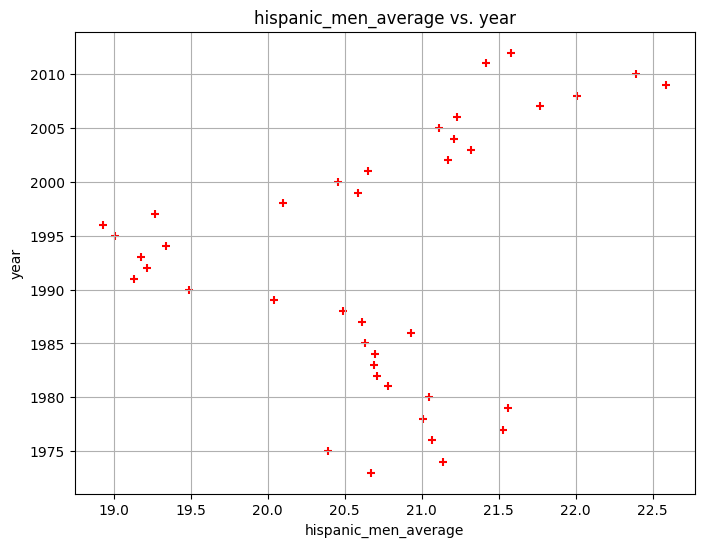

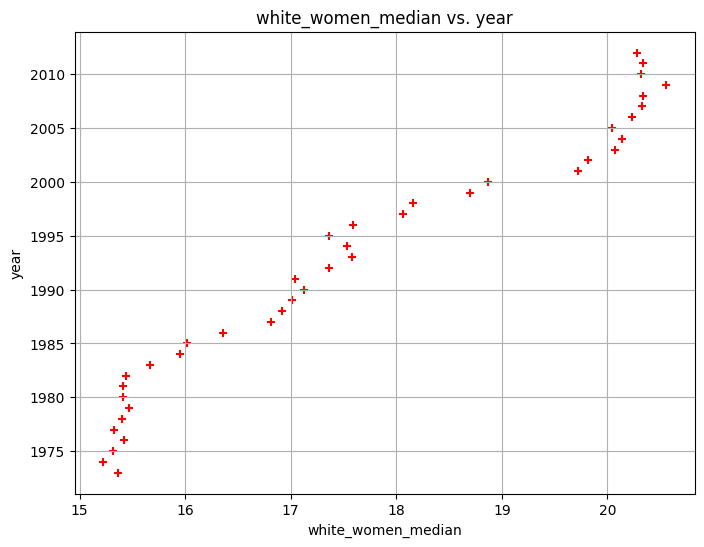

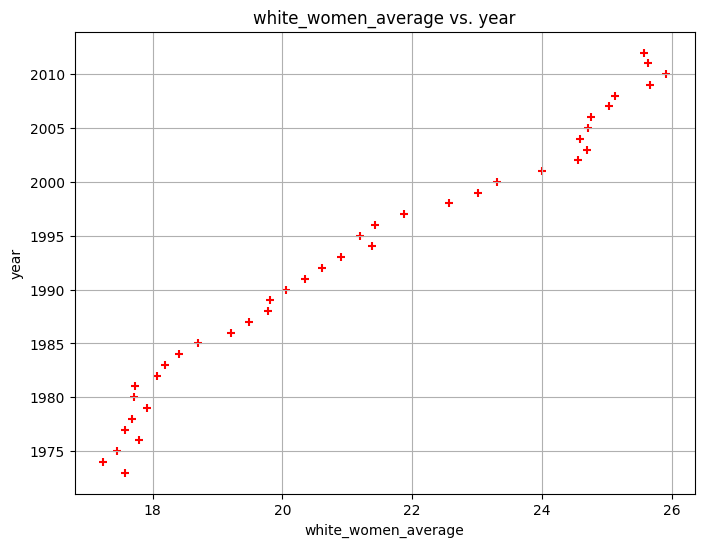

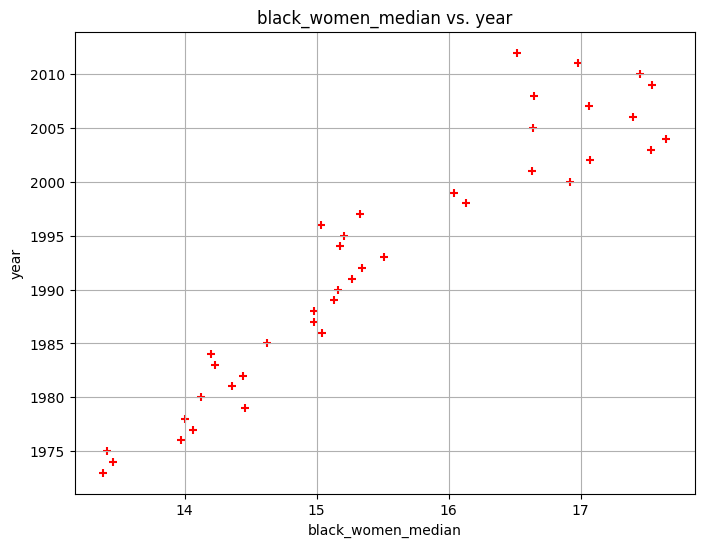

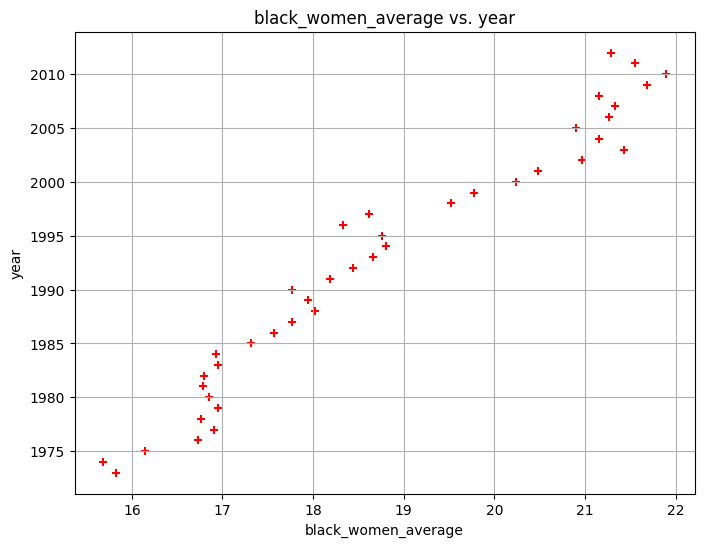

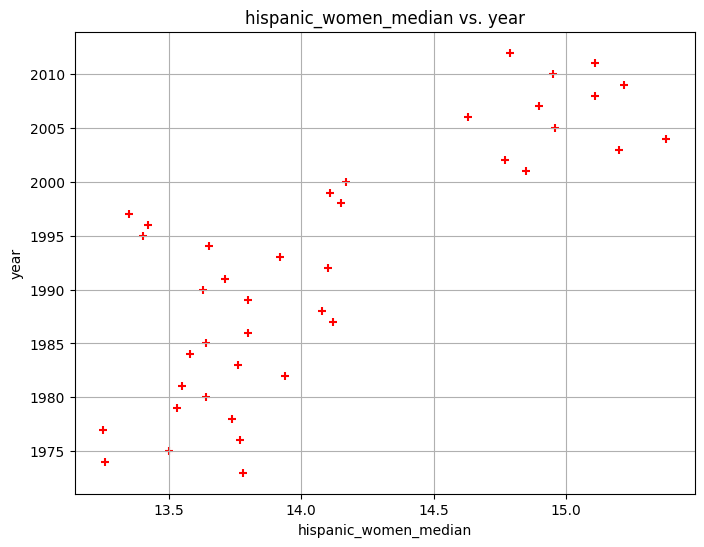

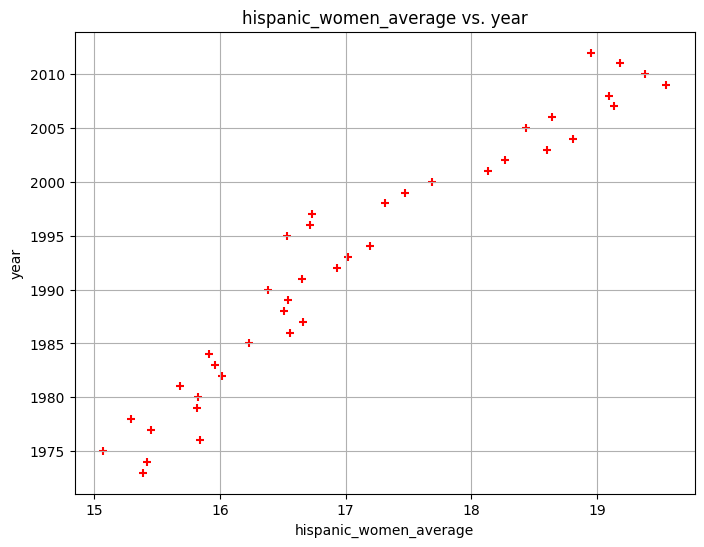

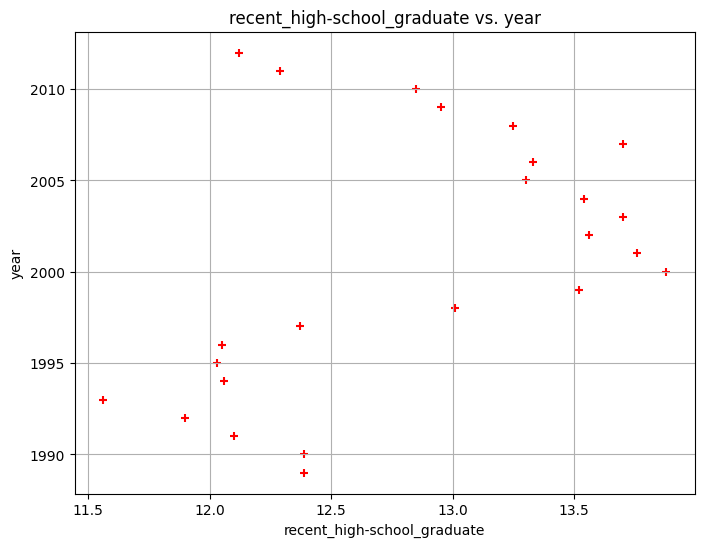

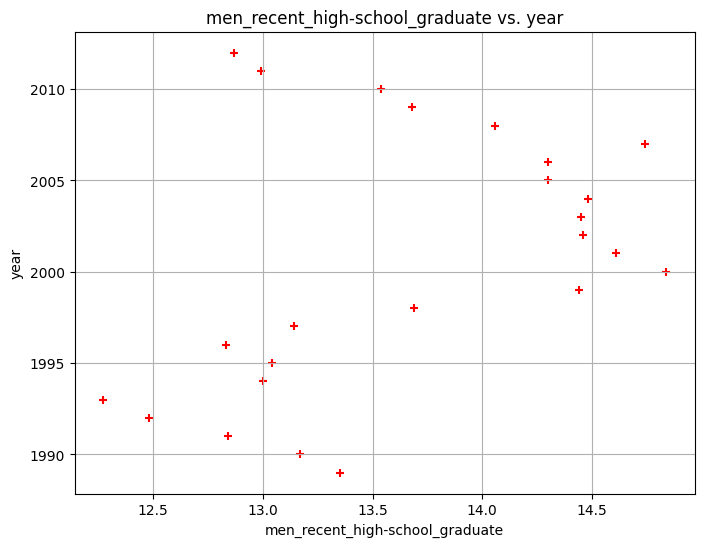

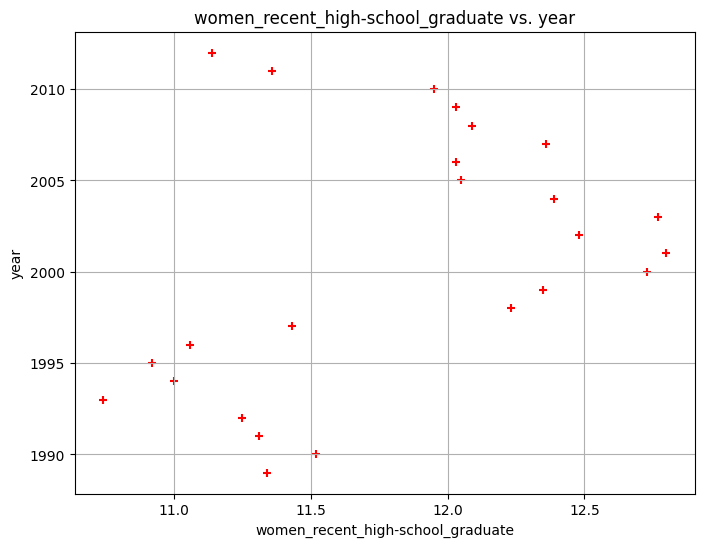

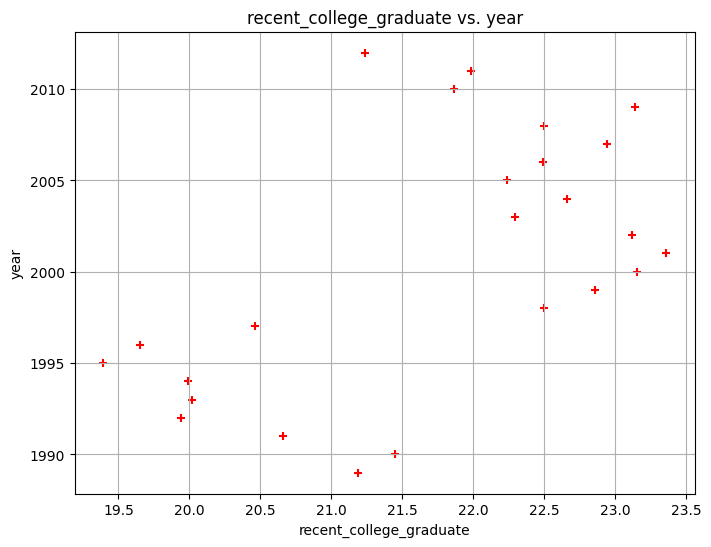

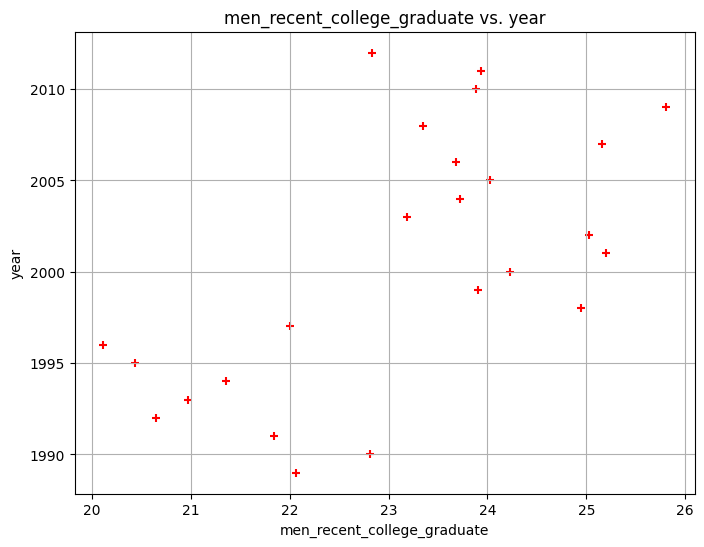

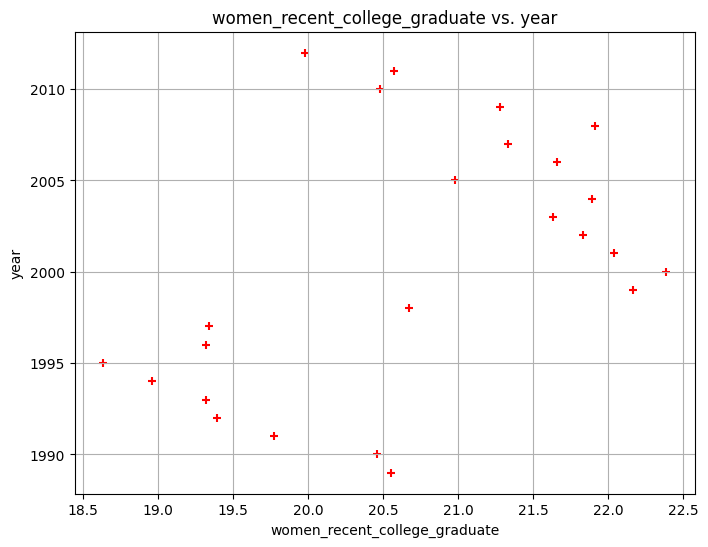

In [198]:
i = 1
for df in group_train:
    a = wage_data.columns[i]
    b = wage_data.columns[0]
    plt.figure(figsize=(8,6))
    aligned = pd.concat([df, year_train], axis = 1, keys = [a, b]).dropna()
    plt.scatter(aligned[a], aligned[b], color='red', marker='+')
    plt.title(a + " vs. " + b)
    plt.grid(True)
    plt.xlabel(a)
    plt.ylabel(b)
    plt.show()
    plt.close()
    i+=1

In [199]:
correlation_storage = sorted(correlation_storage, key=lambda x: abs(x[1]))
print(f"Top five least likely to support linear models: {[x[0] for x in correlation_storage[:5]]} with a value of {[x[1] for x in correlation_storage[:5]]} ")
print(f"Top five most likely to support linear models: {[x[0] for x in correlation_storage[-5:]]} with a value of {[x[1] for x in correlation_storage[-5:]]}")

median_storage= sorted(median_storage, key=lambda x: abs(x[1]))
print()
print(f"Bottom Ten columns based on medians: {[x[0] for x in median_storage[:10]]} with a value of {[x[1] for x in median_storage[:10]]} ")
print(f"Top Ten columns based on medians: {[x[0] for x in median_storage[-10:]]} with a value of {[x[1] for x in median_storage[-10:]]}")

Top five least likely to support linear models: ['black_men_median', 'hispanic_median', 'hispanic_men_average', 'men_median', 'women_recent_high-school_graduate'] with a value of [-0.01800624750459173, -0.07982271577897085, 0.2296387120662246, -0.296969590750943, 0.4159876979311408] 
Top five most likely to support linear models: ['black_women_average', 'women_median', 'white_women_median', 'women_average', 'white_women_average'] with a value of [0.9760672710599382, 0.9764693117738396, 0.9767660575996558, 0.9845331319803365, 0.9845572893146696]

Bottom Ten columns based on medians: ['women_recent_high-school_graduate', 'recent_high-school_graduate', 'men_recent_high-school_graduate', 'hispanic_women_median', 'black_women_median', 'hispanic_median', 'black_median', 'hispanic_women_average', 'women_median', 'hispanic_men_median'] with a value of [11.989999999999998, 12.899999999999999, 13.61, 13.86, 15.195, 15.715, 16.295, 16.689999999999998, 16.75, 16.895] 
Top Ten columns based on medi

##  Models

We will begin implementing both the linear regression and ARIMA models.

In [200]:
# --- 1. Setup and Preprocessing ---

wage_data = wage_data.sort_values('year')
# Use test years 2013–2022
train_mask = wage_data['year'] < 2013
test_mask = wage_data['year'] >= 2013

# Your feature/target splits
X_train = wage_data.loc[train_mask, ['year']].values.reshape(-1, 1)
X_test = wage_data.loc[test_mask, ['year']].values.reshape(-1, 1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("Setup complete. Ready for modeling.")

Setup complete. Ready for modeling.


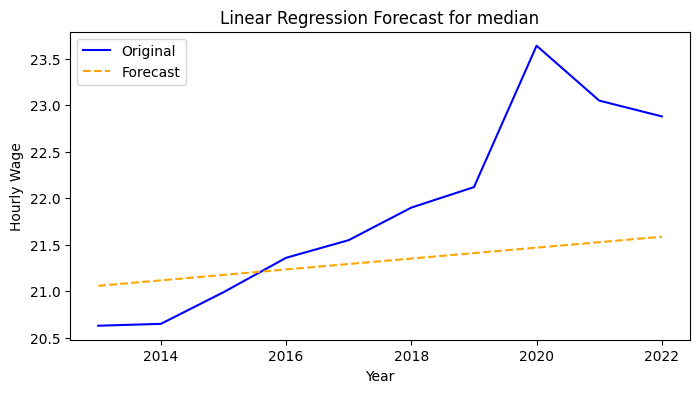


--- Linear Regression Results for 'median' ---
Intercept (c): 19.86
Coefficients: [0.6765015]
Model Equation: y = 0.68 * Year (Scaled) + 19.86
RMSE: 1.0012


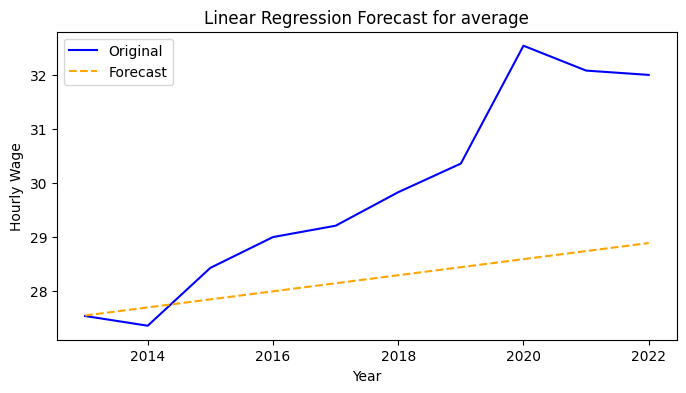


--- Linear Regression Results for 'average' ---
Intercept (c): 24.50
Coefficients: [1.71892651]
Model Equation: y = 1.72 * Year (Scaled) + 24.50
RMSE: 2.1222


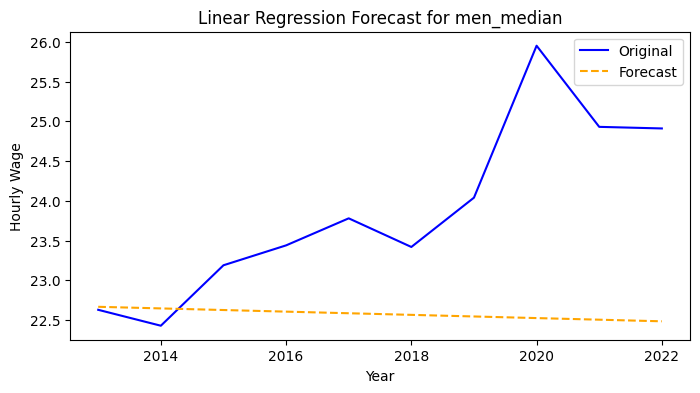


--- Linear Regression Results for 'men_median' ---
Intercept (c): 23.08
Coefficients: [-0.23388914]
Model Equation: y = -0.23 * Year (Scaled) + 23.08
RMSE: 1.7006


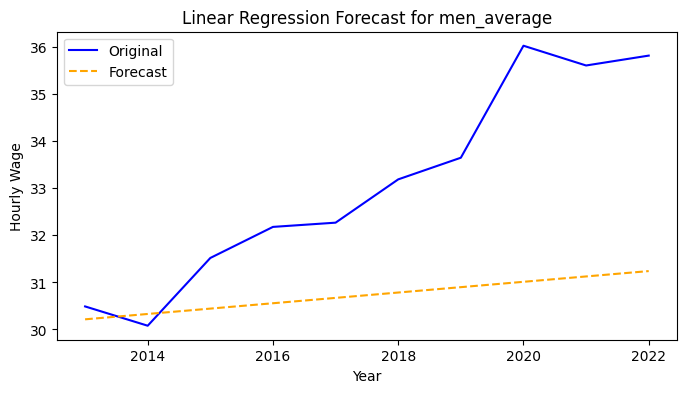


--- Linear Regression Results for 'men_average' ---
Intercept (c): 27.88
Coefficients: [1.31491846]
Model Equation: y = 1.31 * Year (Scaled) + 27.88
RMSE: 2.9336


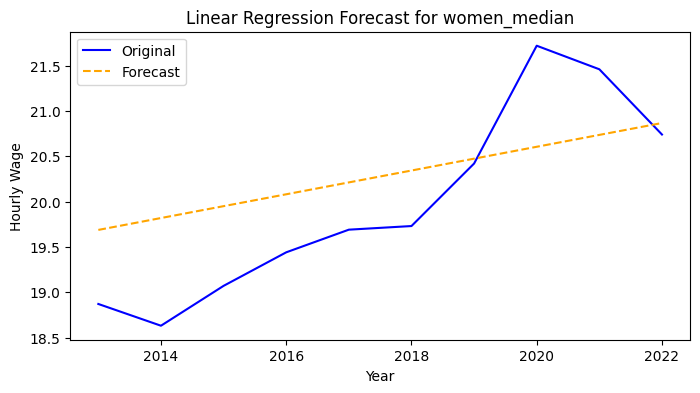


--- Linear Regression Results for 'women_median' ---
Intercept (c): 17.00
Coefficients: [1.51294294]
Model Equation: y = 1.51 * Year (Scaled) + 17.00
RMSE: 0.7549


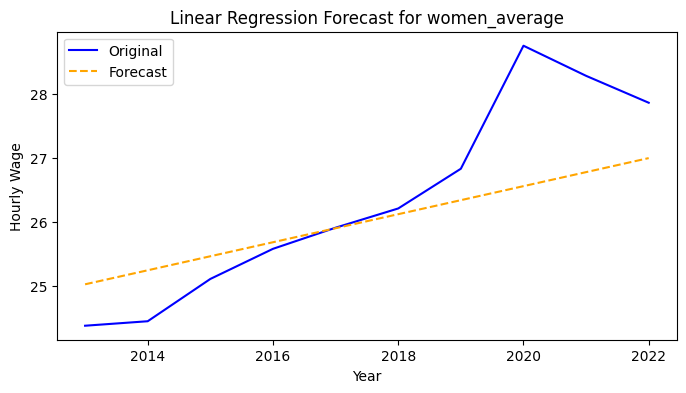


--- Linear Regression Results for 'women_average' ---
Intercept (c): 20.54
Coefficients: [2.5261521]
Model Equation: y = 2.53 * Year (Scaled) + 20.54
RMSE: 0.9614


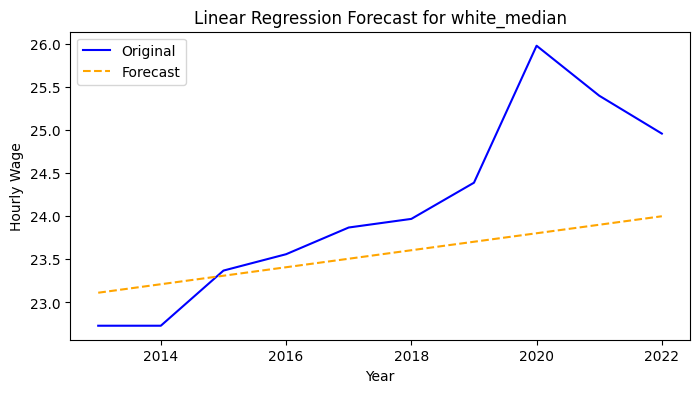


--- Linear Regression Results for 'white_median' ---
Intercept (c): 21.09
Coefficients: [1.13843227]
Model Equation: y = 1.14 * Year (Scaled) + 21.09
RMSE: 0.9508


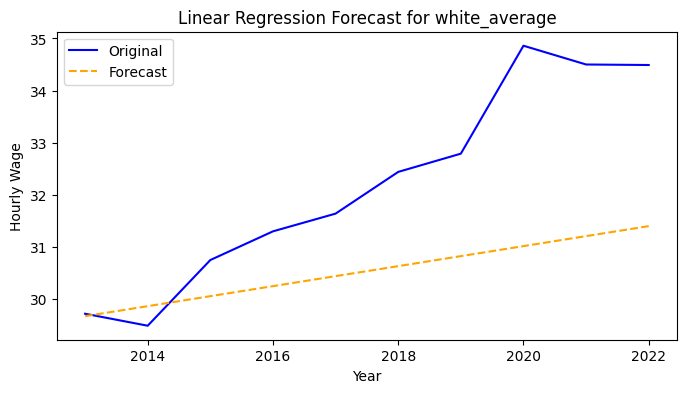


--- Linear Regression Results for 'white_average' ---
Intercept (c): 25.74
Coefficients: [2.21519509]
Model Equation: y = 2.22 * Year (Scaled) + 25.74
RMSE: 2.1318


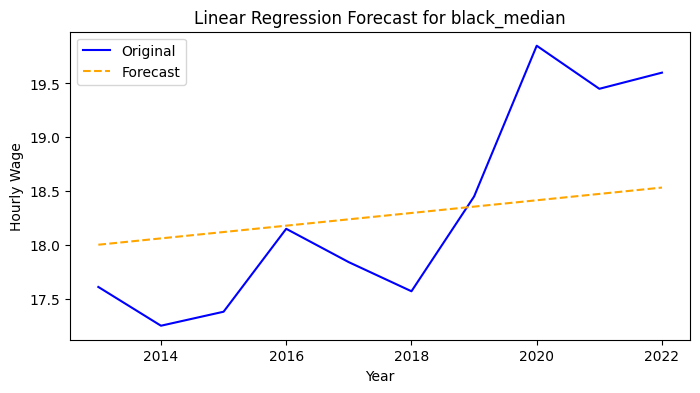


--- Linear Regression Results for 'black_median' ---
Intercept (c): 16.79
Coefficients: [0.68082216]
Model Equation: y = 0.68 * Year (Scaled) + 16.79
RMSE: 0.7878


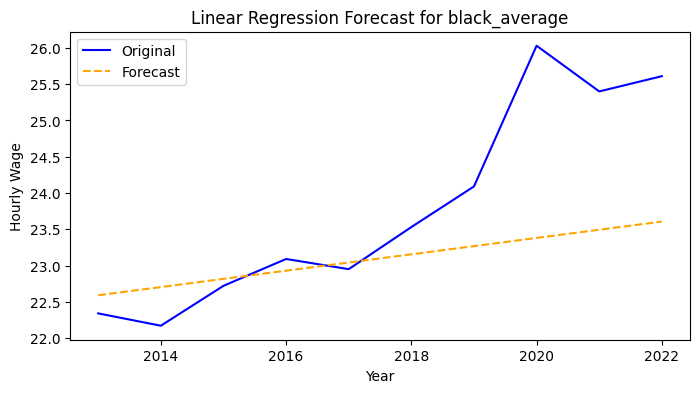


--- Linear Regression Results for 'black_average' ---
Intercept (c): 20.28
Coefficients: [1.30301772]
Model Equation: y = 1.30 * Year (Scaled) + 20.28
RMSE: 1.2602


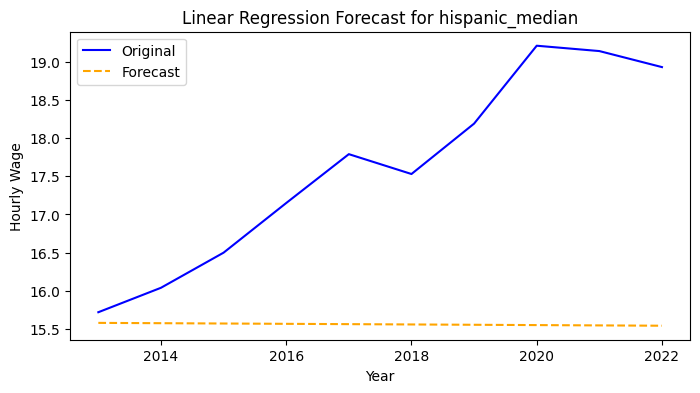


--- Linear Regression Results for 'hispanic_median' ---
Intercept (c): 15.67
Coefficients: [-0.0477654]
Model Equation: y = -0.05 * Year (Scaled) + 15.67
RMSE: 2.3904


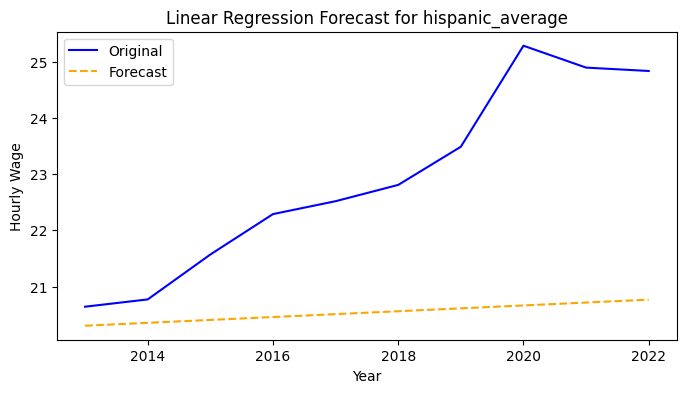


--- Linear Regression Results for 'hispanic_average' ---
Intercept (c): 19.24
Coefficients: [0.59590347]
Model Equation: y = 0.60 * Year (Scaled) + 19.24
RMSE: 2.7919


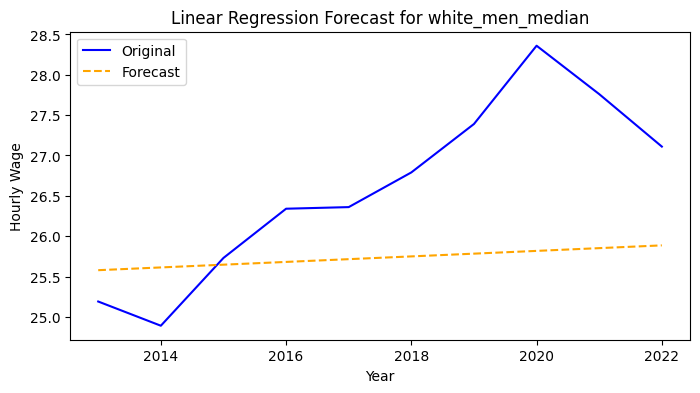


--- Linear Regression Results for 'white_men_median' ---
Intercept (c): 24.88
Coefficients: [0.39441381]
Model Equation: y = 0.39 * Year (Scaled) + 24.88
RMSE: 1.2962


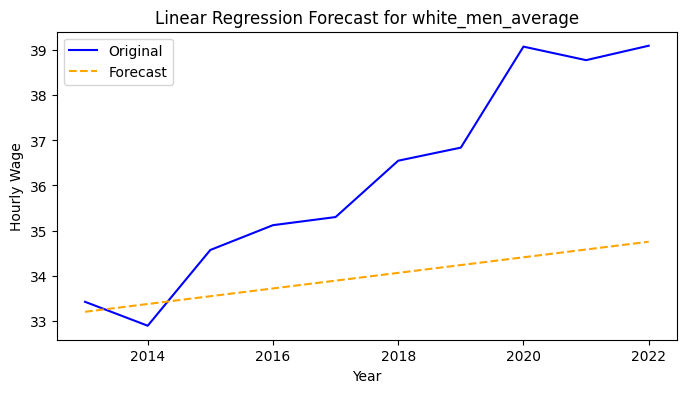


--- Linear Regression Results for 'white_men_average' ---
Intercept (c): 29.66
Coefficients: [1.99354239]
Model Equation: y = 1.99 * Year (Scaled) + 29.66
RMSE: 2.7681


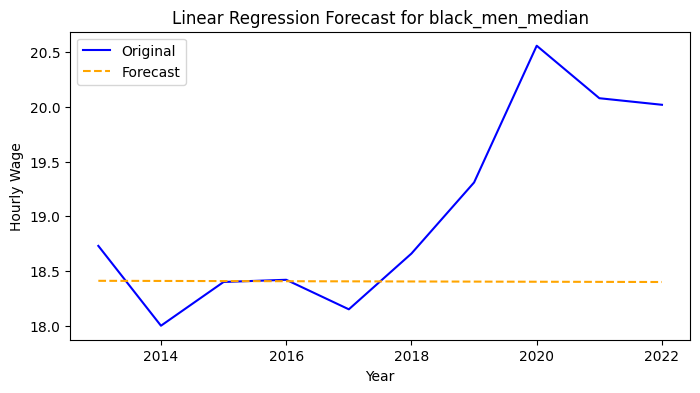


--- Linear Regression Results for 'black_men_median' ---
Intercept (c): 18.44
Coefficients: [-0.01401234]
Model Equation: y = -0.01 * Year (Scaled) + 18.44
RMSE: 1.0641


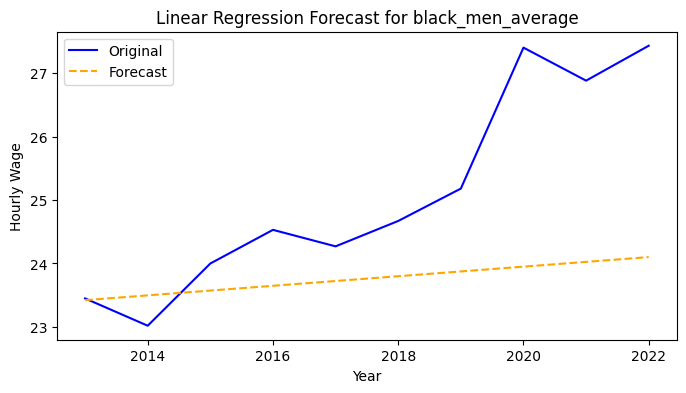


--- Linear Regression Results for 'black_men_average' ---
Intercept (c): 21.88
Coefficients: [0.86981549]
Model Equation: y = 0.87 * Year (Scaled) + 21.88
RMSE: 1.8728


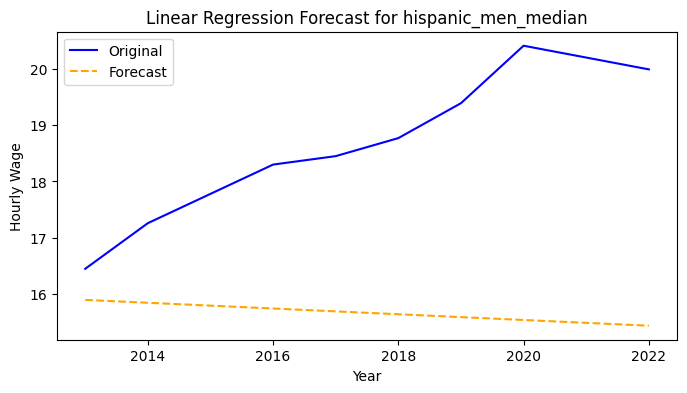


--- Linear Regression Results for 'hispanic_men_median' ---
Intercept (c): 16.94
Coefficients: [-0.58800935]
Model Equation: y = -0.59 * Year (Scaled) + 16.94
RMSE: 3.3338


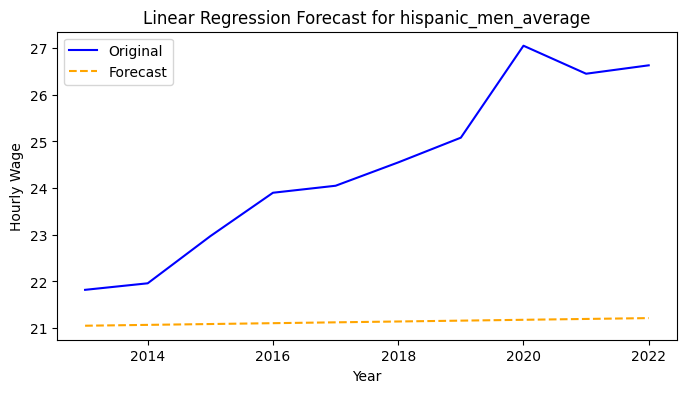


--- Linear Regression Results for 'hispanic_men_average' ---
Intercept (c): 20.68
Coefficients: [0.20937295]
Model Equation: y = 0.21 * Year (Scaled) + 20.68
RMSE: 3.7376


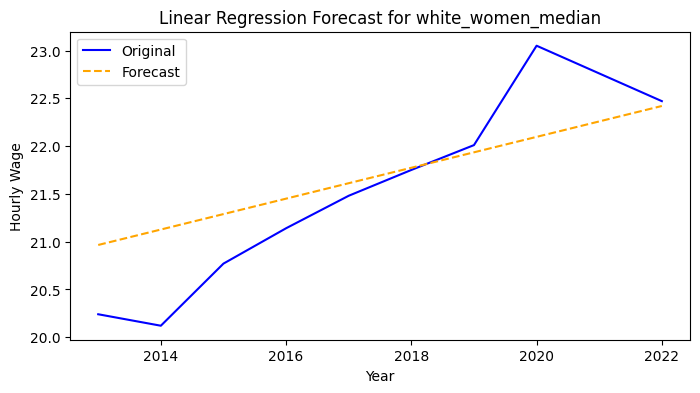


--- Linear Regression Results for 'white_women_median' ---
Intercept (c): 17.65
Coefficients: [1.8653847]
Model Equation: y = 1.87 * Year (Scaled) + 17.65
RMSE: 0.5560


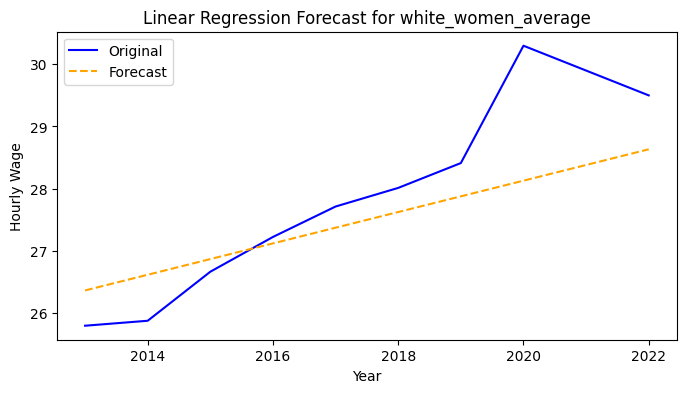


--- Linear Regression Results for 'white_women_average' ---
Intercept (c): 21.18
Coefficients: [2.91562803]
Model Equation: y = 2.92 * Year (Scaled) + 21.18
RMSE: 0.9629


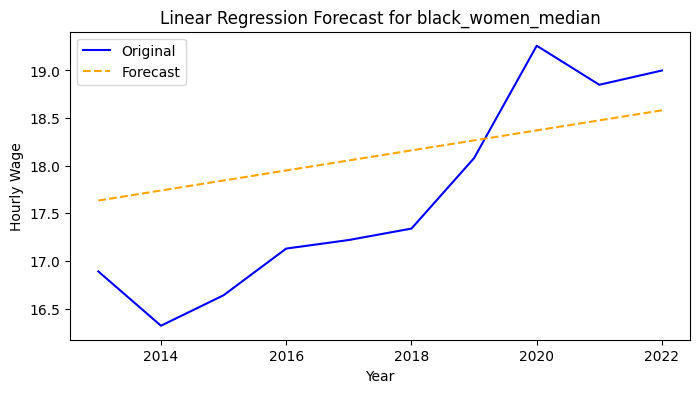


--- Linear Regression Results for 'black_women_median' ---
Intercept (c): 15.48
Coefficients: [1.21487208]
Model Equation: y = 1.21 * Year (Scaled) + 15.48
RMSE: 0.8488


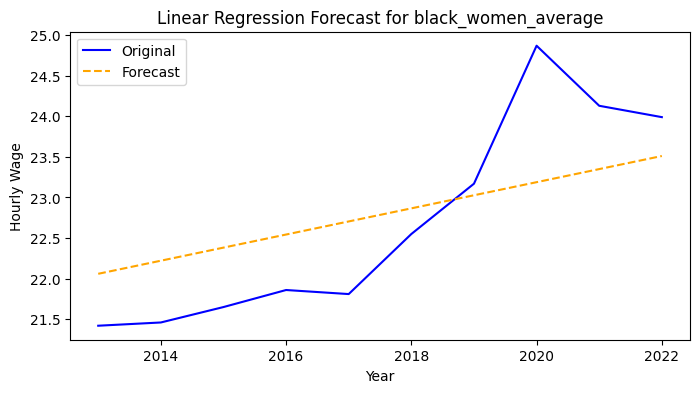


--- Linear Regression Results for 'black_women_average' ---
Intercept (c): 18.75
Coefficients: [1.8614972]
Model Equation: y = 1.86 * Year (Scaled) + 18.75
RMSE: 0.8111


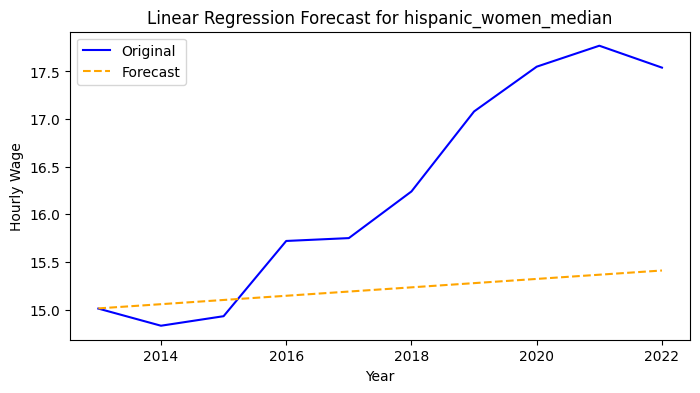


--- Linear Regression Results for 'hispanic_women_median' ---
Intercept (c): 14.11
Coefficients: [0.51040004]
Model Equation: y = 0.51 * Year (Scaled) + 14.11
RMSE: 1.4239


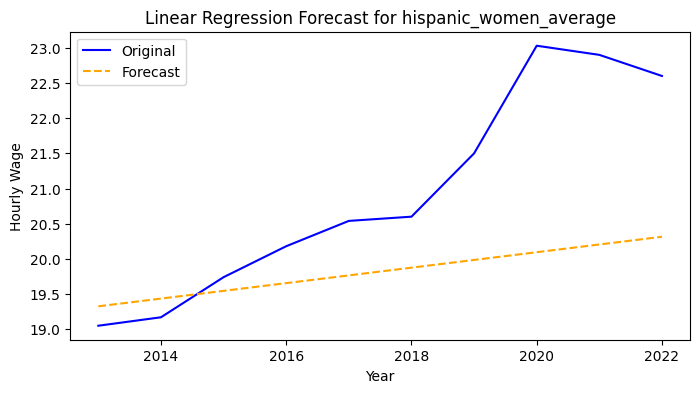


--- Linear Regression Results for 'hispanic_women_average' ---
Intercept (c): 17.07
Coefficients: [1.26799769]
Model Equation: y = 1.27 * Year (Scaled) + 17.07
RMSE: 1.5807


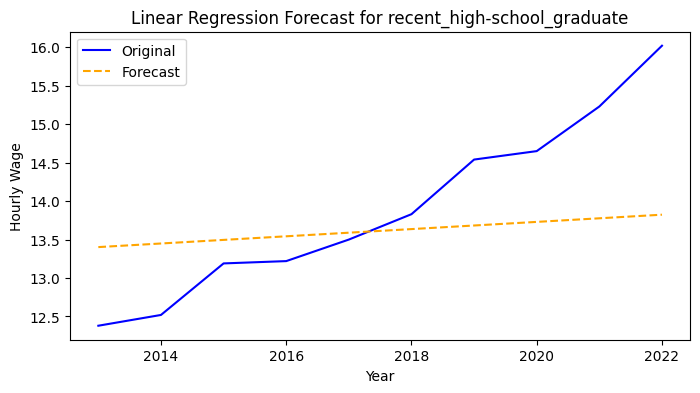


--- Linear Regression Results for 'recent_high-school_graduate' ---
Intercept (c): 12.44
Coefficients: [0.54028114]
Model Equation: y = 0.54 * Year (Scaled) + 12.44
RMSE: 1.0329


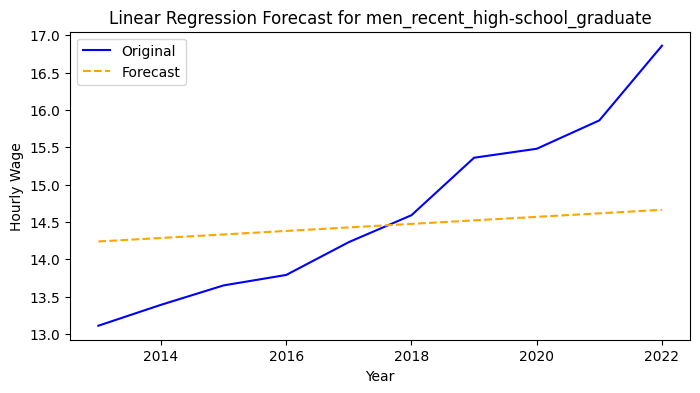


--- Linear Regression Results for 'men_recent_high-school_graduate' ---
Intercept (c): 13.27
Coefficients: [0.54429623]
Model Equation: y = 0.54 * Year (Scaled) + 13.27
RMSE: 1.0418


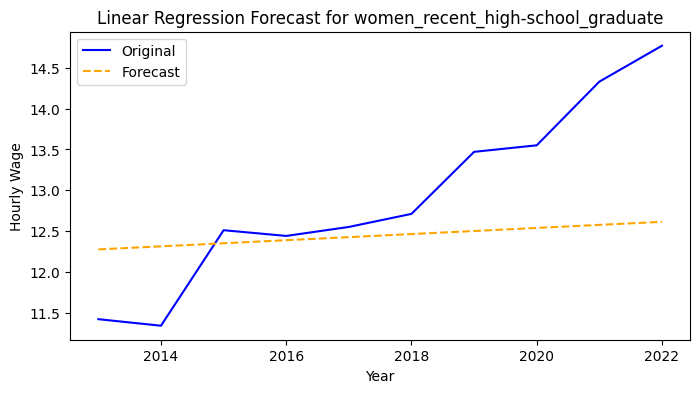


--- Linear Regression Results for 'women_recent_high-school_graduate' ---
Intercept (c): 11.50
Coefficients: [0.43358001]
Model Equation: y = 0.43 * Year (Scaled) + 11.50
RMSE: 1.0713


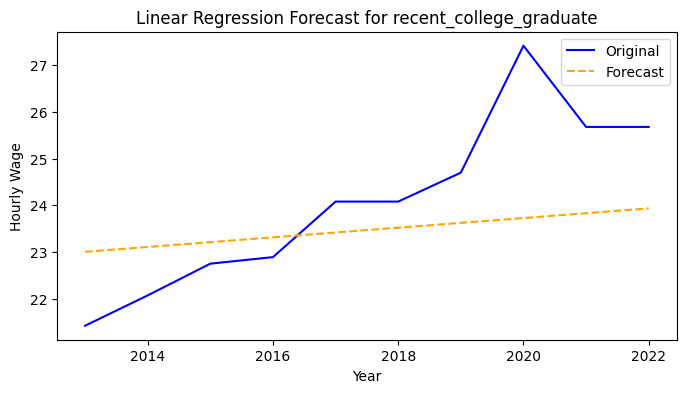


--- Linear Regression Results for 'recent_college_graduate' ---
Intercept (c): 20.88
Coefficients: [1.19338643]
Model Equation: y = 1.19 * Year (Scaled) + 20.88
RMSE: 1.6120


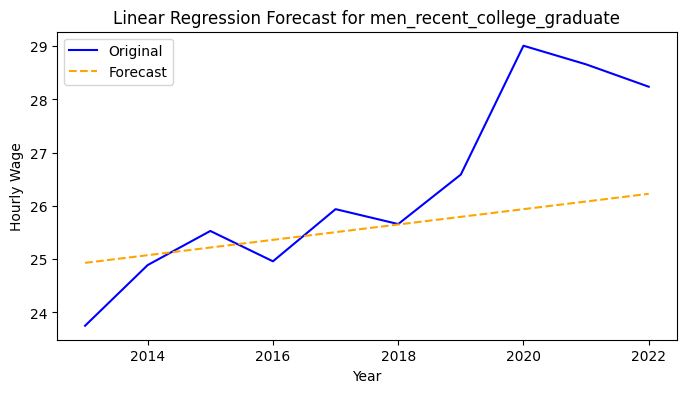


--- Linear Regression Results for 'men_recent_college_graduate' ---
Intercept (c): 21.98
Coefficients: [1.66290153]
Model Equation: y = 1.66 * Year (Scaled) + 21.98
RMSE: 1.5041


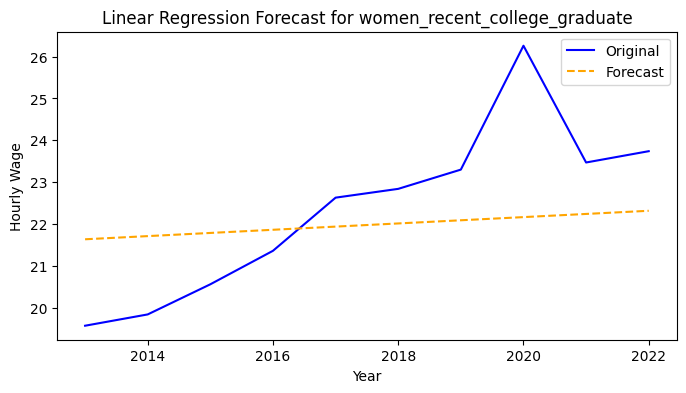


--- Linear Regression Results for 'women_recent_college_graduate' ---
Intercept (c): 20.08
Coefficients: [0.8734336]
Model Equation: y = 0.87 * Year (Scaled) + 20.08
RMSE: 1.8016


In [201]:
target_columns = wage_data[1:]

lin_reg_RMSE = {}

for col in target_columns:
    y_train_full = wage_data.loc[train_mask, col].values
    y_test_full = wage_data.loc[test_mask, col].values

    # Remove missing targets synchronously
    train_mask_nan = ~np.isnan(y_train_full)
    X_train_valid = X_train_scaled[train_mask_nan]
    y_train_valid = y_train_full[train_mask_nan]

    test_mask_nan = ~np.isnan(y_test_full)
    X_test_valid = X_test_scaled[test_mask_nan]
    y_test_valid = y_test_full[test_mask_nan]

    lr_model = LinearRegression()
    lr_model.fit(X_train_valid, y_train_valid)
    lr_predictions = lr_model.predict(X_test_valid)

    lr_mse = mean_squared_error(y_test_valid, lr_predictions)
    lr_rmse = np.sqrt(lr_mse)

    # Residuals
    residuals = y_test_valid - lr_predictions

    if col.lower() != 'year':

        # Xtest: actual test year values, not scaled
        # ytestvalid: actual hourly wage (test/validation set)
        # lrpredictions: predictions from your linear regression model

        plt.figure(figsize=(8, 4))
        plt.plot(X_test.flatten(), y_test_valid, label='Original', color='blue')  # Solid line: actual
        plt.plot(X_test.flatten(), lr_predictions, label='Forecast', color='orange', linestyle='--')  # Dashed: predicted
        plt.title(f'Linear Regression Forecast for {col}')
        plt.xlabel('Year')
        plt.ylabel('Hourly Wage')
        plt.legend()
        plt.show()

        # --- OLS Regression Summary ---
        print(f"\n--- Linear Regression Results for '{col}' ---")
        print(f"Intercept (c): {lr_model.intercept_:.2f}")
        print(f"Coefficients: {lr_model.coef_}")
        print(f"Model Equation: y = {lr_model.coef_[0]:.2f} * Year (Scaled) + {lr_model.intercept_:.2f}")
        print(f"RMSE: {lr_rmse:.4f}")

        lin_reg_RMSE[col] = lr_rmse



In [202]:
arima_df = wage_data[:]
arima_df["year"] = pd.to_datetime(arima_df["year"], format="%Y")
arima_df = arima_df.sort_values("year")
arima_df = arima_df.set_index("year")
arima_df.index = arima_df.index.to_period('Y')
forcast_results = []
metrics = []

In [203]:
from statsmodels.tsa.api import VAR
df_filled = arima_df.interpolate(method="linear", limit_direction="both")
df_diff = df_filled.diff().dropna()
train = df_diff[:-split]
test = df_diff.tail(split)
model = VAR(train)
results = model.fit(maxlags=3)
lag_order = results.k_ar
forecast_input = train.values[-lag_order:]
forecast = results.forecast(y=forecast_input, steps=len(test))
forecast_df = pd.DataFrame(forecast, index=test.index, columns=df_diff.columns)
df_diff.index = df_diff.index.to_timestamp()
forecast_df.index = forecast_df.index.to_timestamp()

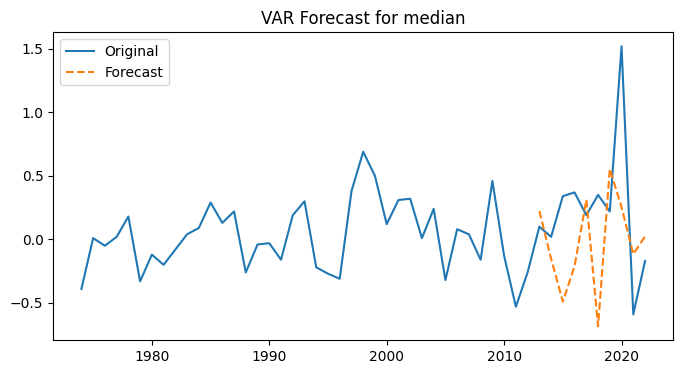

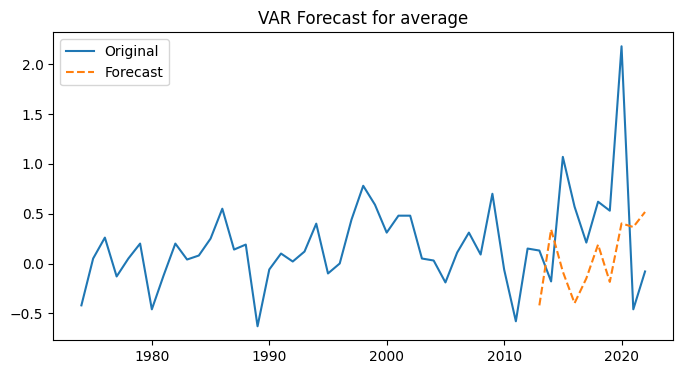

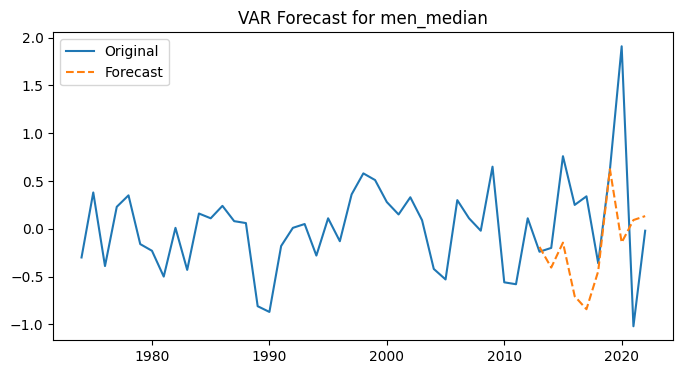

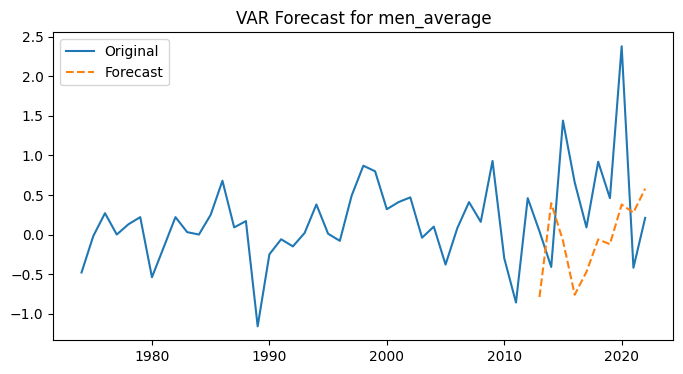

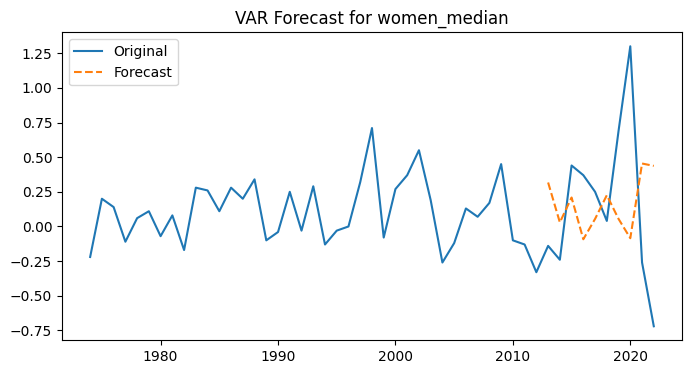

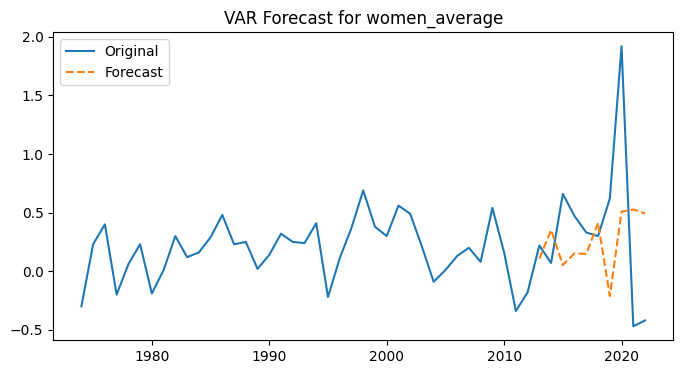

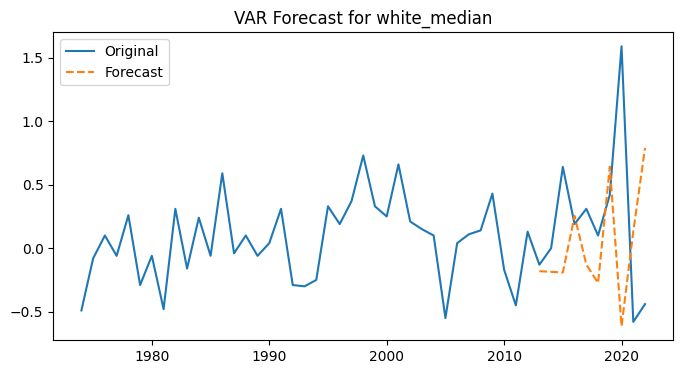

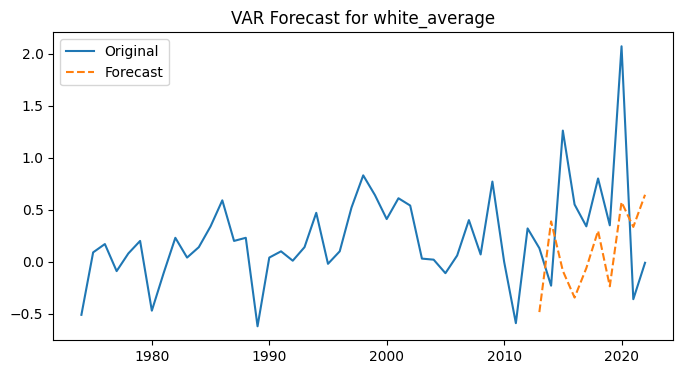

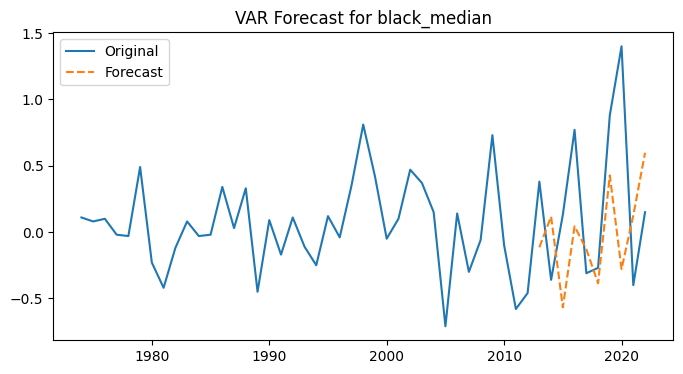

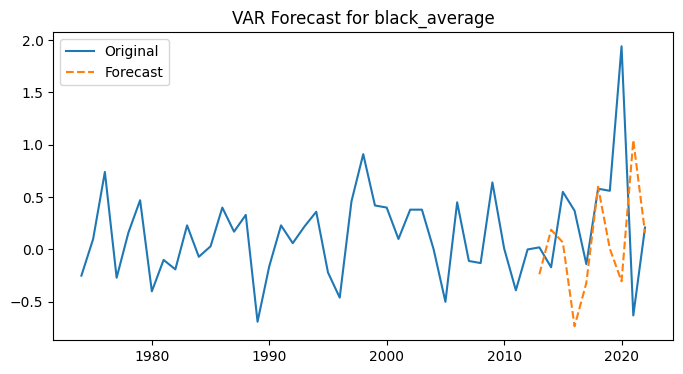

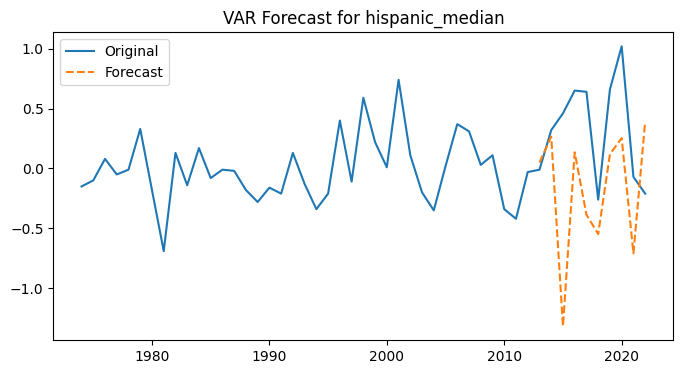

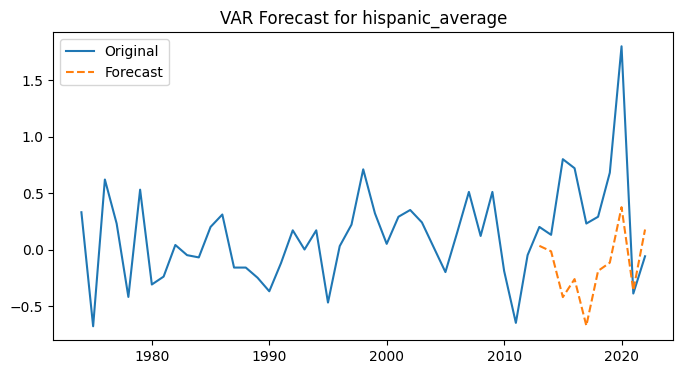

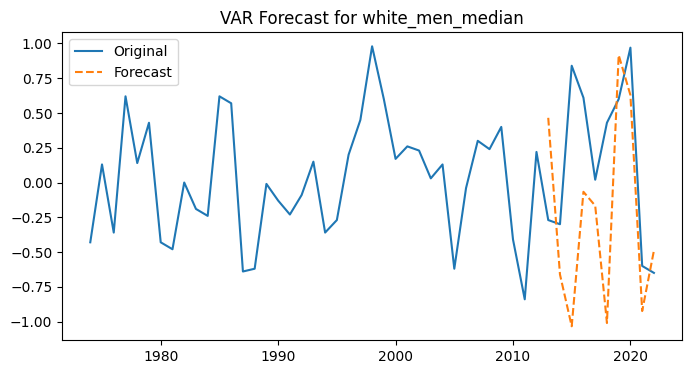

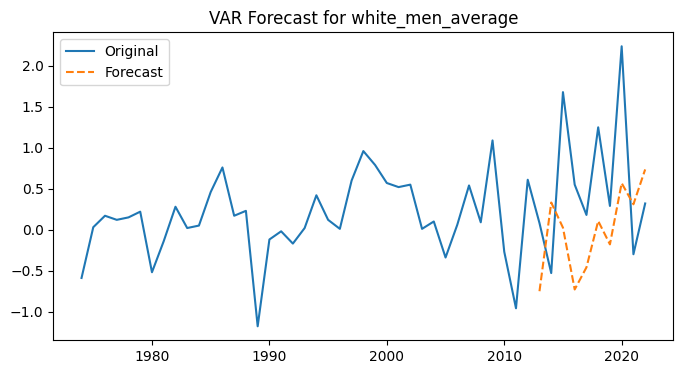

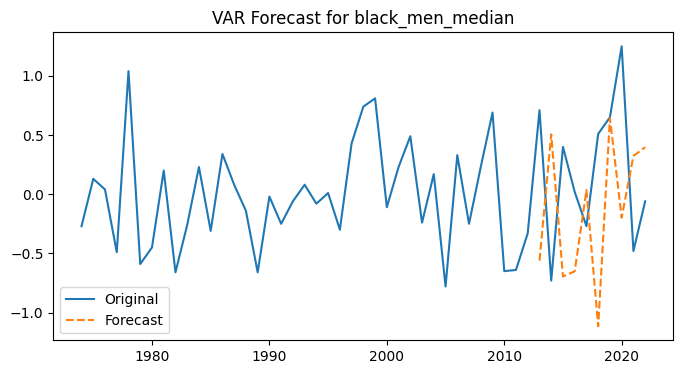

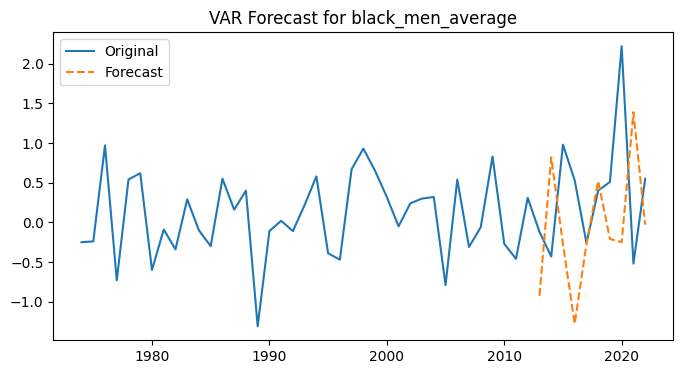

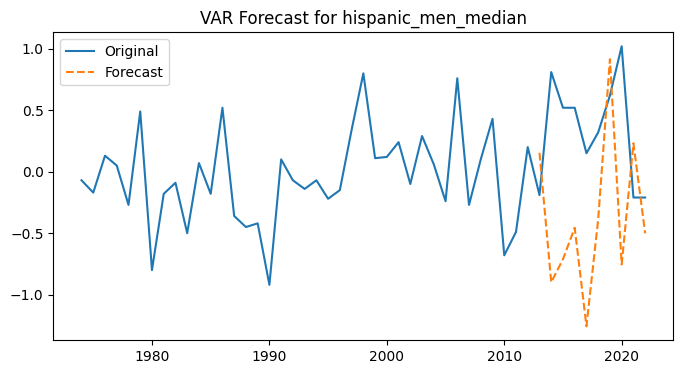

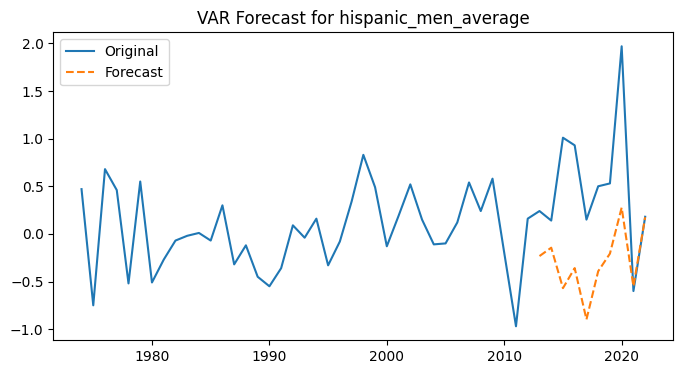

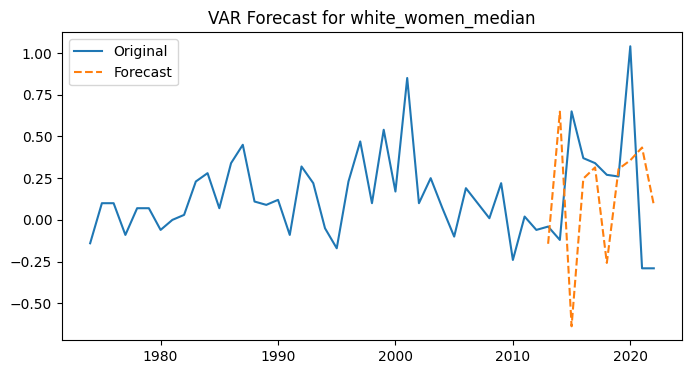

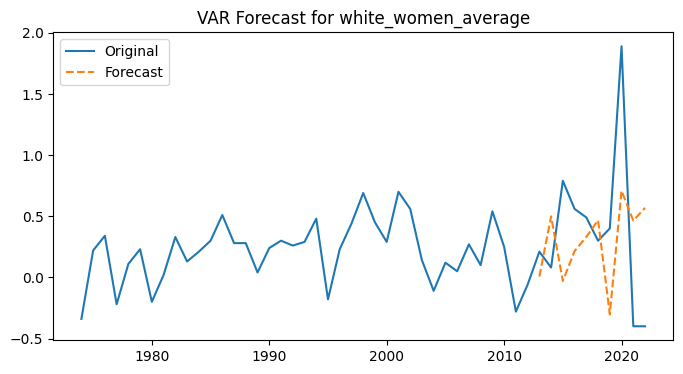

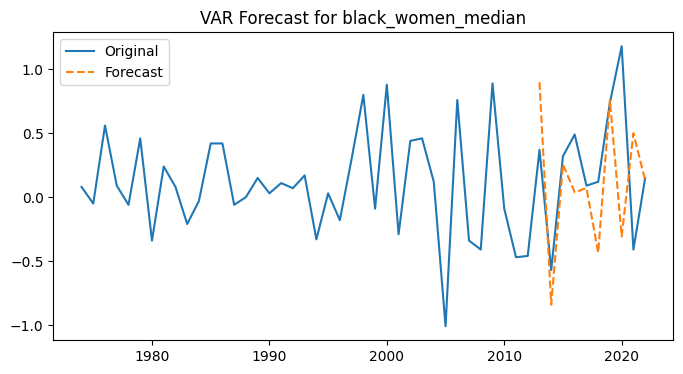

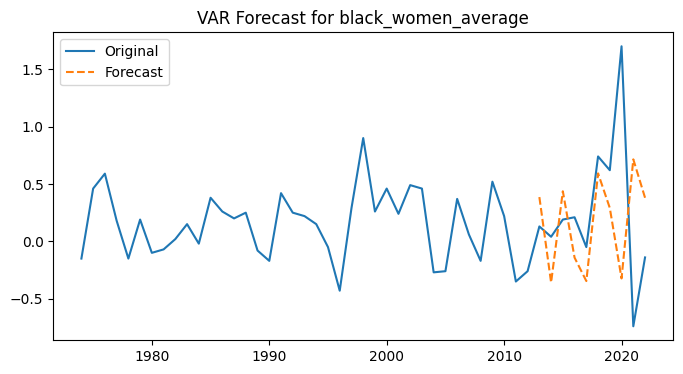

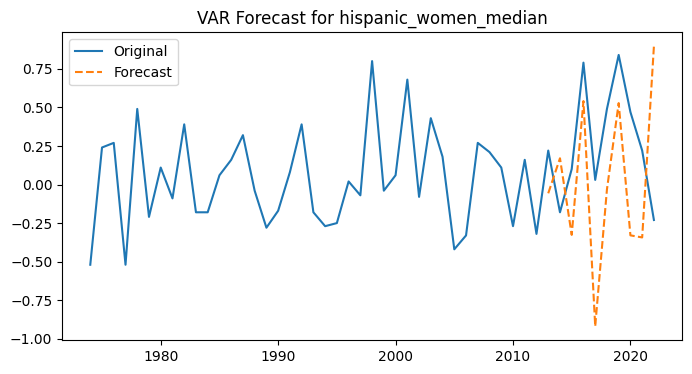

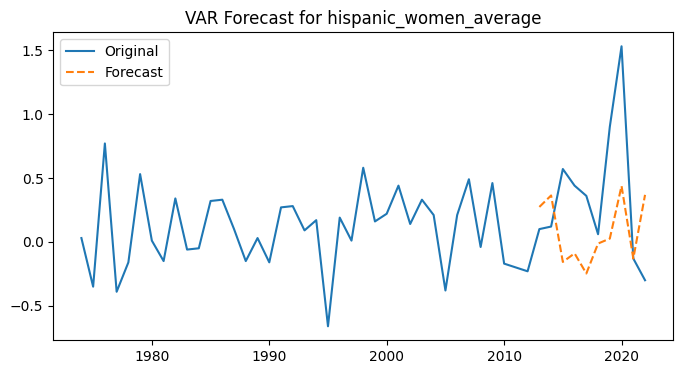

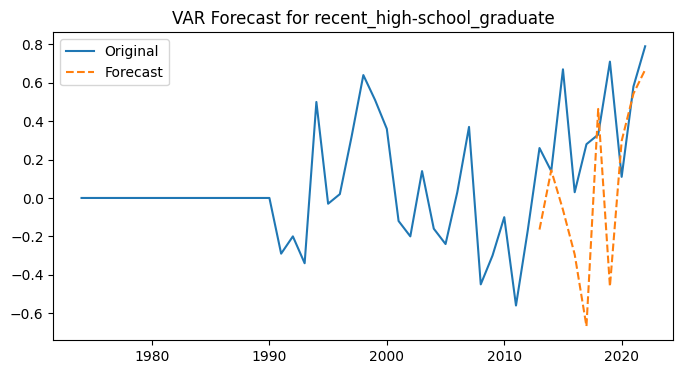

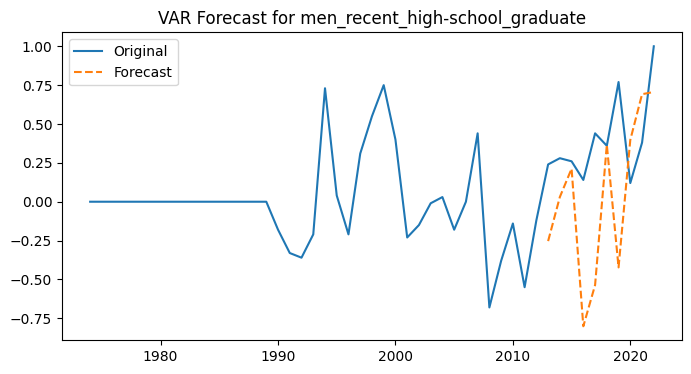

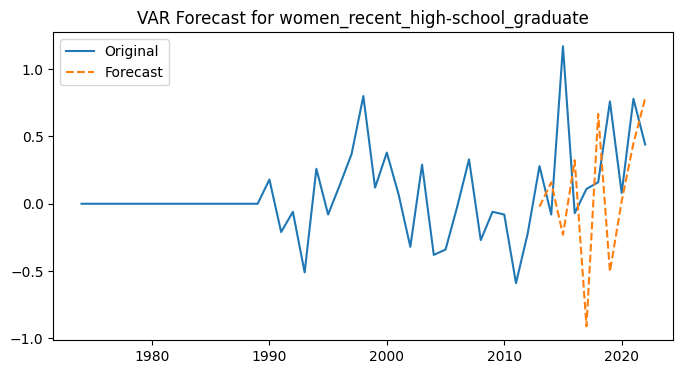

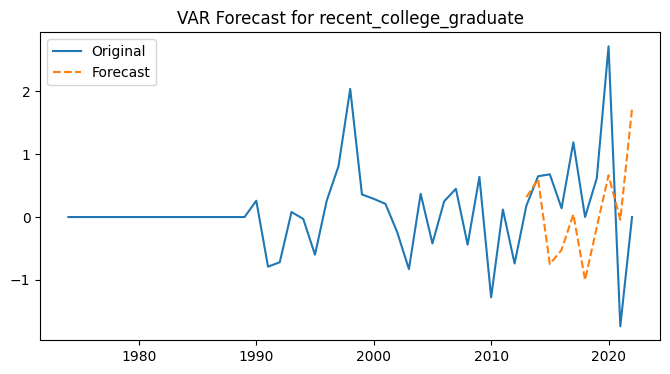

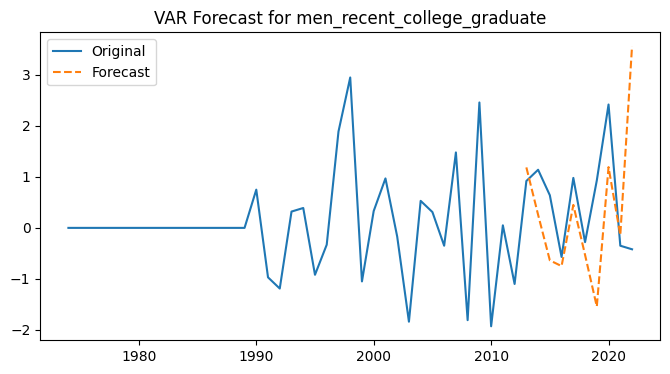

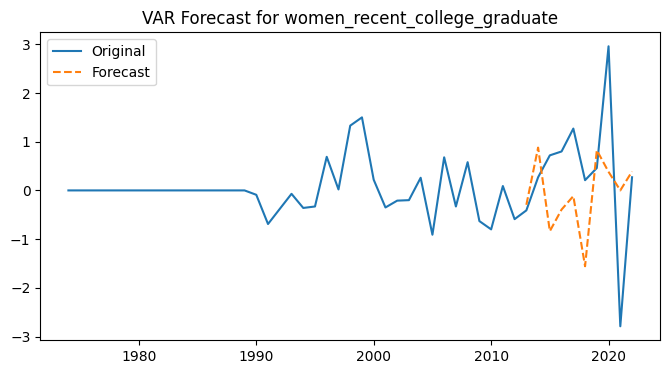

In [204]:
for col in df_diff.columns:
    plt.figure(figsize=(8,4))
    plt.plot(df_diff.index, df_diff[col], label="Original")
    plt.plot(forecast_df.index, forecast_df[col], label="Forecast", linestyle="--")
    plt.title(f"VAR Forecast for {col}")
    plt.legend()
    plt.show()
    plt.close()

##  Evaluation Metrics

We will now give the RMSE of our models

In [205]:
print("RMSE ARIMA Linear Regression per column:")
for col, rmse in lin_reg_RMSE.items():
    print(f"{col}: {rmse:.4f}")

RMSE ARIMA Linear Regression per column:
median: 1.0012
average: 2.1222
men_median: 1.7006
men_average: 2.9336
women_median: 0.7549
women_average: 0.9614
white_median: 0.9508
white_average: 2.1318
black_median: 0.7878
black_average: 1.2602
hispanic_median: 2.3904
hispanic_average: 2.7919
white_men_median: 1.2962
white_men_average: 2.7681
black_men_median: 1.0641
black_men_average: 1.8728
hispanic_men_median: 3.3338
hispanic_men_average: 3.7376
white_women_median: 0.5560
white_women_average: 0.9629
black_women_median: 0.8488
black_women_average: 0.8111
hispanic_women_median: 1.4239
hispanic_women_average: 1.5807
recent_high-school_graduate: 1.0329
men_recent_high-school_graduate: 1.0418
women_recent_high-school_graduate: 1.0713
recent_college_graduate: 1.6120
men_recent_college_graduate: 1.5041
women_recent_college_graduate: 1.8016


In [206]:
sorted_lin_reg_rmse = dict(sorted(lin_reg_RMSE.items(), key= lambda item: item[1]))
print()
print()
print(f"Bottom five based on RMSE: {[x[0] for x in list(sorted_lin_reg_rmse.items())[:5]]} with a value of {[x[1] for x in list(sorted_lin_reg_rmse.items())[:5]]} ")
print()
print(f"Top five based on RMSE: {[x[0] for x in list(sorted_lin_reg_rmse.items())[-5:]]} with a value of {[x[1] for x in list(sorted_lin_reg_rmse.items())[-5:]]}")





Bottom five based on RMSE: ['white_women_median', 'women_median', 'black_median', 'black_women_average', 'black_women_median'] with a value of [0.5560031090225246, 0.7548920830465655, 0.7878232419878306, 0.8110569005903773, 0.8488451661823262] 

Top five based on RMSE: ['white_men_average', 'hispanic_average', 'men_average', 'hispanic_men_median', 'hispanic_men_average'] with a value of [2.7681443637555687, 2.7918567449267147, 2.933585991348229, 3.3338494023682332, 3.7376110529980124]


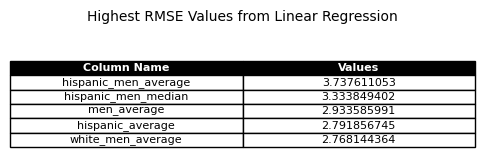

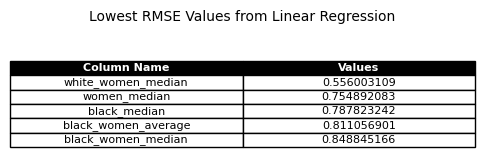

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Linear Regression RMSE Data ---

# Highest RMSE
highest_rmse_data = {
    "Column Name": [
        "hispanic_men_average",
        "hispanic_men_median",
        "men_average",
        "hispanic_average",
        "white_men_average",
    ],
    "Values": [
        3.737611053,
        3.333849402,
        2.933585991,
        2.791856745,
        2.768144364,
    ],
}

# Lowest RMSE
lowest_rmse_data = {
    "Column Name": [
        "white_women_median",
        "women_median",
        "black_median",
        "black_women_average",
        "black_women_median",
    ],
    "Values": [
        0.556003109,
        0.754892083,
        0.787823242,
        0.811056901,
        0.848845166,
    ],
}

# Convert to DataFrames
highest_rmse_df = pd.DataFrame(highest_rmse_data)
lowest_rmse_df = pd.DataFrame(lowest_rmse_data)

# --- Function to display styled tables ---
def plot_rmse_table(df, title):
    fig, ax = plt.subplots(figsize=(6, 1.1 + len(df) * 0.1))
    ax.axis("off")
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center",
        bbox=[0, 0, 1, 0.7],

    )
    
    # Style header
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("black")
            cell.set_text_props(color="white", weight="bold")
        else:
            cell.set_facecolor("white")
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    ax.set_title(title, fontsize=10, pad=0.5)
    
    plt.show()

plot_rmse_table(highest_rmse_df, "Highest RMSE Values from Linear Regression")
plot_rmse_table(lowest_rmse_df, "Lowest RMSE Values from Linear Regression")


In [208]:
overall_rmse = np.sqrt(mean_squared_error(test.values, forecast_df.values))
print(f"Overall RMSE for VAR: {overall_rmse:.4f}")

Overall RMSE for VAR: 0.9270


In [209]:
rmse_dict = {}

for col in test.columns:
    rmse = np.sqrt(mean_squared_error(test[col], forecast_df[col]))
    rmse_dict[col] = rmse

print("RMSE ARIMA VAR per column:")
for col, rmse in rmse_dict.items():
    print(f"{col}: {rmse:.4f}")


RMSE ARIMA VAR per column:
median: 0.6430
average: 0.8868
men_median: 0.9304
men_average: 1.0912
women_median: 0.6922
women_average: 0.7154
white_median: 0.8941
white_average: 0.8533
black_median: 0.7096
black_average: 0.9910
hispanic_median: 0.7885
hispanic_average: 0.7923
white_men_median: 0.8426
white_men_average: 1.0532
black_men_median: 1.0237
black_men_average: 1.3292
hispanic_men_median: 1.0724
hispanic_men_average: 0.9884
white_women_median: 0.6074
white_women_average: 0.6809
black_women_median: 0.6254
black_women_average: 0.8430
hispanic_women_median: 0.6275
hispanic_women_average: 0.6062
recent_high-school_graduate: 0.5621
men_recent_high-school_graduate: 0.6188
women_recent_high-school_graduate: 0.7342
recent_college_graduate: 1.2450
men_recent_college_graduate: 1.6242
women_recent_college_graduate: 1.5446


In [210]:
sorted_rmse = dict(sorted(rmse_dict.items(), key= lambda item: item[1]))
print()
print()
print(f"Bottom five based on RMSE: {[x[0] for x in list(sorted_rmse.items())[:5]]} with a value of {[x[1] for x in list(sorted_rmse.items())[:5]]} ")
print()
print(f"Top five based on RMSE: {[x[0] for x in list(sorted_rmse.items())[-5:]]} with a value of {[x[1] for x in list(sorted_rmse.items())[-5:]]}")





Bottom five based on RMSE: ['recent_high-school_graduate', 'hispanic_women_average', 'white_women_median', 'men_recent_high-school_graduate', 'black_women_median'] with a value of [0.5620945488319895, 0.606203828706579, 0.607356430261054, 0.6187968223357523, 0.6254145397343932] 

Top five based on RMSE: ['men_average', 'recent_college_graduate', 'black_men_average', 'women_recent_college_graduate', 'men_recent_college_graduate'] with a value of [1.0912178925857514, 1.2450104442206866, 1.3292434710877232, 1.5446201526178114, 1.6241760736748625]
